In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from master_thesis.simple_models.model_evaluator import ModelEvaluator
import pandas as pd
import numpy as np

In [7]:
model_evaluator = ModelEvaluator(
    results_dir="../results/ml_models/",
    scoring_metric="f1",
    seeds= [25, 80, 44, 27, 35]
)
model_evaluater2 = ModelEvaluator(
    results_dir="../results/ml_models_f2/",
    scoring_metric="f2",
    seeds= [25, 80, 44, 27, 35]
)
df_train = pd.read_csv("../processed_data/train_features_standardized.csv")
df_val = pd.read_csv("../processed_data/val_features_standardized.csv")

In [4]:
df_train.head()

,rr_mean,rr_std,rmssd,r_amp_mean,r_amp_std,qrs_energy_mean,qrs_energy_std,signal_std,signal_skew,signal_kurtosis,...,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag,sex,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,age_at_ecg
0,-1.278853,-0.453750,-0.393829,-0.685825,-0.182205,-0.145712,-0.217333,0.661558,-0.644227,-1.621666,...,0,0,0,1.0,1.669724,1.649000,0.625016,0.331119,0.968852,0.252431
1,-0.801409,-0.347694,-0.359864,0.248337,-0.166327,-0.466849,-0.267627,-0.390942,0.772772,0.159547,...,0,0,0,0.0,0.482879,0.766159,0.219933,-0.257717,-0.951410,-0.096770
2,-0.365354,-0.355443,-0.351136,1.515458,0.181236,0.449374,0.106814,1.068025,0.359841,-0.472950,...,1,0,1,1.0,-2.453001,0.128552,-0.072626,0.019382,-0.494205,0.801176
3,0.560215,-0.274770,-0.275539,-0.703555,-0.505422,-0.767046,-0.372299,-1.185808,0.566452,-0.306332,...,0,0,1,1.0,0.545344,-0.754290,-0.477709,-0.119167,-0.677087,-0.645516
4,-0.485013,0.854047,0.771885,-1.203619,-0.332691,-0.807123,-0.331112,-1.223928,-0.576821,-1.495485,...,0,0,1,1.0,-0.454104,0.324738,0.084906,-2.474513,4.260728,3.220643


In [5]:
df_val.head()

,rr_mean,rr_std,rmssd,r_amp_mean,r_amp_std,qrs_energy_mean,qrs_energy_std,signal_std,signal_skew,signal_kurtosis,...,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag,sex,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,age_at_ecg
0,0.123512,-0.417225,-0.372810,0.259570,-0.475648,-0.449163,-0.342511,-0.538553,0.936411,0.675515,...,0,0,1,1.0,1.169999,-0.361916,-0.297672,0.538944,0.054441,0.427032
1,-0.928009,-0.444285,-0.382900,-0.480238,-0.450756,-0.751793,-0.358726,-1.065881,0.873907,0.449650,...,1,1,1,0.0,-0.516570,0.962346,0.309952,0.331119,-1.408615,-2.167036
2,-1.069504,-0.408815,-0.380517,-0.328861,-0.194217,-0.665722,-0.299954,-0.762833,0.441435,-0.448434,...,0,0,0,0.0,-1.828346,1.207580,0.422475,-0.292355,-1.317174,-0.870002
3,-0.794675,-0.448886,-0.391229,1.770862,-0.342939,0.778132,-0.228009,1.292547,0.668804,-0.204861,...,0,0,0,0.0,-0.079311,0.766159,0.219933,0.054020,-0.585646,-0.495858
4,-0.733876,-0.398463,-0.336434,1.139366,0.131944,0.629985,-0.058509,1.187812,0.326031,-0.677933,...,1,1,1,1.0,1.482327,0.668066,0.174924,0.573581,-0.219882,0.526804


In [6]:
df_train = df_train.drop(columns=[col for col in df_train.columns if 'flag' in col.lower() and col != 'shd_moderate_or_greater_flag'])
df_val = df_val.drop(columns=[col for col in df_val.columns if 'flag' in col.lower() and col != 'shd_moderate_or_greater_flag'])

df_train.head()

,rr_mean,rr_std,rmssd,r_amp_mean,r_amp_std,qrs_energy_mean,qrs_energy_std,signal_std,signal_skew,signal_kurtosis,fft_energy,shd_moderate_or_greater_flag,sex,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,age_at_ecg
0,-1.278853,-0.453750,-0.393829,-0.685825,-0.182205,-0.145712,-0.217333,0.661558,-0.644227,-1.621666,0.358884,0,1.0,1.669724,1.649000,0.625016,0.331119,0.968852,0.252431
1,-0.801409,-0.347694,-0.359864,0.248337,-0.166327,-0.466849,-0.267627,-0.390942,0.772772,0.159547,-0.403277,0,0.0,0.482879,0.766159,0.219933,-0.257717,-0.951410,-0.096770
2,-0.365354,-0.355443,-0.351136,1.515458,0.181236,0.449374,0.106814,1.068025,0.359841,-0.472950,0.748623,1,1.0,-2.453001,0.128552,-0.072626,0.019382,-0.494205,0.801176
3,0.560215,-0.274770,-0.275539,-0.703555,-0.505422,-0.767046,-0.372299,-1.185808,0.566452,-0.306332,-0.742744,1,1.0,0.545344,-0.754290,-0.477709,-0.119167,-0.677087,-0.645516
4,-0.485013,0.854047,0.771885,-1.203619,-0.332691,-0.807123,-0.331112,-1.223928,-0.576821,-1.495485,-0.753805,1,1.0,-0.454104,0.324738,0.084906,-2.474513,4.260728,3.220643


In [7]:
df_val.head()

,rr_mean,rr_std,rmssd,r_amp_mean,r_amp_std,qrs_energy_mean,qrs_energy_std,signal_std,signal_skew,signal_kurtosis,fft_energy,shd_moderate_or_greater_flag,sex,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,age_at_ecg
0,0.123512,-0.417225,-0.372810,0.259570,-0.475648,-0.449163,-0.342511,-0.538553,0.936411,0.675515,-0.481628,1,1.0,1.169999,-0.361916,-0.297672,0.538944,0.054441,0.427032
1,-0.928009,-0.444285,-0.382900,-0.480238,-0.450756,-0.751793,-0.358726,-1.065881,0.873907,0.449650,-0.704563,1,0.0,-0.516570,0.962346,0.309952,0.331119,-1.408615,-2.167036
2,-1.069504,-0.408815,-0.380517,-0.328861,-0.194217,-0.665722,-0.299954,-0.762833,0.441435,-0.448434,-0.587103,0,0.0,-1.828346,1.207580,0.422475,-0.292355,-1.317174,-0.870002
3,-0.794675,-0.448886,-0.391229,1.770862,-0.342939,0.778132,-0.228009,1.292547,0.668804,-0.204861,0.989008,0,0.0,-0.079311,0.766159,0.219933,0.054020,-0.585646,-0.495858
4,-0.733876,-0.398463,-0.336434,1.139366,0.131944,0.629985,-0.058509,1.187812,0.326031,-0.677933,0.876138,1,1.0,1.482327,0.668066,0.174924,0.573581,-0.219882,0.526804


In [8]:
ecg_feature_cols = [
"rr_mean", "rr_std", "rmssd",
"r_amp_mean", "r_amp_std",
"qrs_energy_mean", "qrs_energy_std",
"signal_std", "signal_skew", "signal_kurtosis",
"fft_energy"
]

df_train = df_train.dropna(subset=ecg_feature_cols, how='all')
df_val = df_val.dropna(subset=ecg_feature_cols, how='all')

In [9]:
# with f1
model_evaluator.tune_all_models(
    X_train=df_train[[col for col in df_train.columns if col != 'shd_moderate_or_greater_flag']],
    y_train=df_train['shd_moderate_or_greater_flag'],
    X_val=df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']],
    y_val=df_val['shd_moderate_or_greater_flag']
)

Models: 100%|██████████| 6/6 [00:00<00:00, 2799.00it/s, model=LogisticRegression]


In [10]:
# with f2
model_evaluater2.tune_all_models(
    X_train=df_train[[col for col in df_train.columns if col != 'shd_moderate_or_greater_flag']],
    y_train=df_train['shd_moderate_or_greater_flag'],
    X_val=df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']],
    y_val=df_val['shd_moderate_or_greater_flag']
)

Models: 100%|██████████| 6/6 [00:00<00:00, 2754.58it/s, model=LogisticRegression]


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 37770, number of negative: 34480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002379 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3759
[LightGBM] [Info] Number of data points in the 

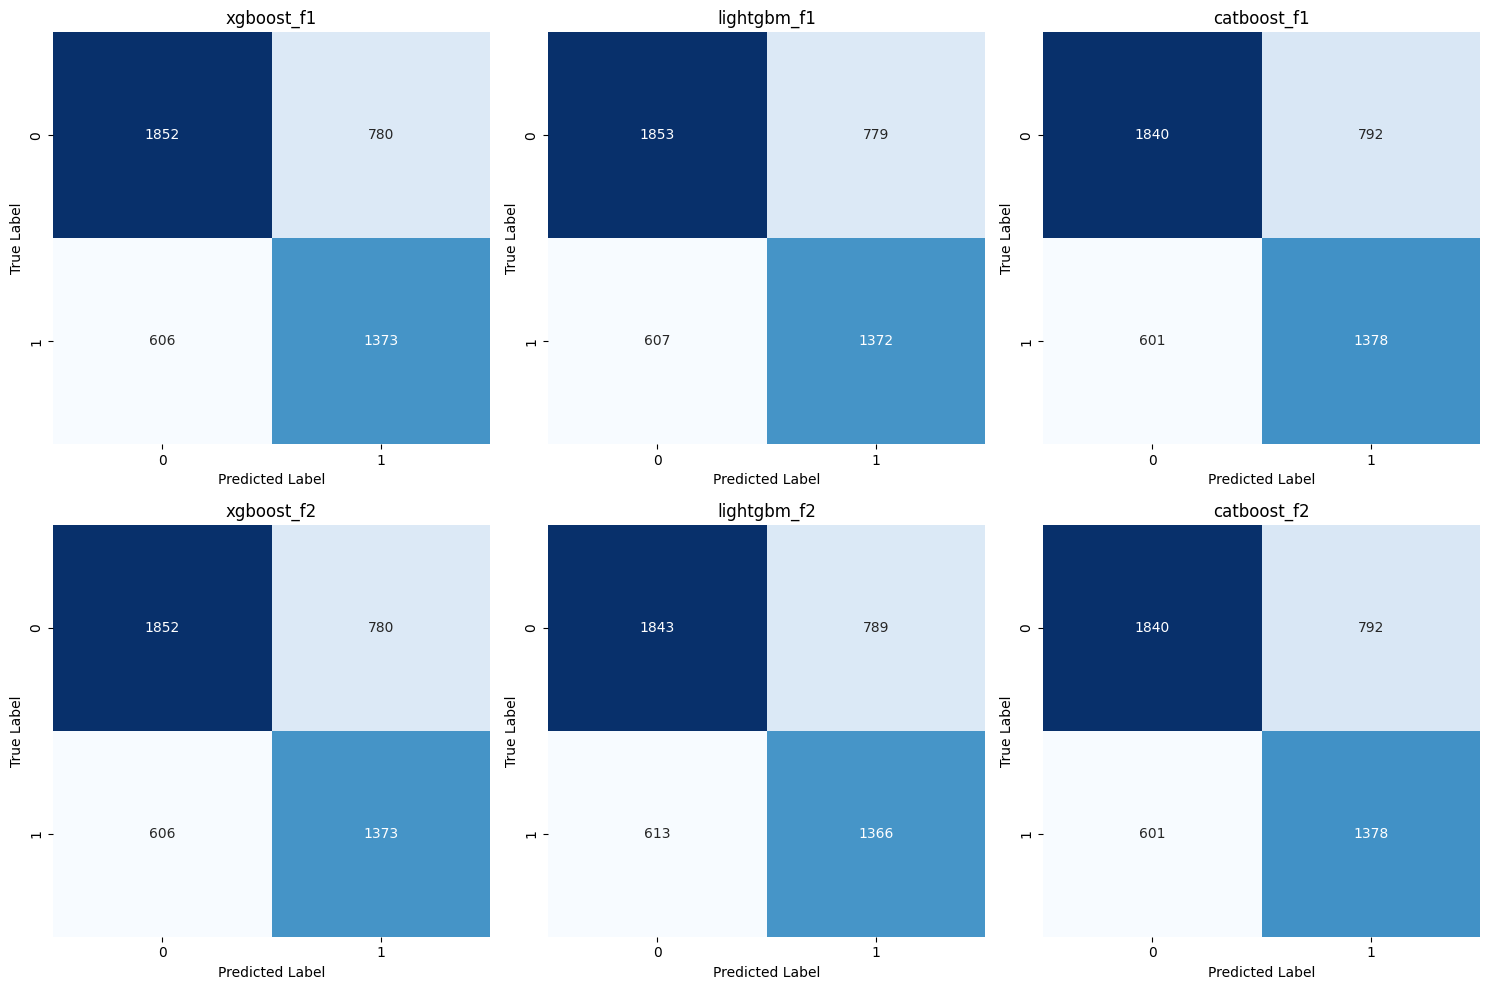

In [11]:
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns


xgboost_f1 = XGBClassifier(
    colsample_bytree= 1.0,
    learning_rate= 0.05,
    max_depth= 6,
    n_estimators= 400,
    reg_lambda= 1,
    subsample= 0.8
)
lightgbm_f1 = LGBMClassifier(
    bagging_fraction= 0.8,
    feature_fraction= 1.0,
    lambda_l2= 10,
    learning_rate= 0.05,
    max_depth= 6,
    n_estimators= 400,
    num_leaves= 63
)
catboost_f1 = CatBoostClassifier(
    depth= 8,
    iterations= 400,
    l2_leaf_reg= 10,
    learning_rate= 0.05
)

xgboost_f2 = XGBClassifier(
    colsample_bytree= 1.0,
    learning_rate= 0.05,
    max_depth= 6,
    n_estimators= 400,
    reg_lambda= 1,
    subsample= 0.8
)

lightgbm_f2 = LGBMClassifier(
    bagging_fraction= 0.8,
    feature_fraction= 0.8,
    lambda_l2= 10,
    learning_rate= 0.05,
    max_depth= 6,
    n_estimators= 400,
    num_leaves= 31
)

catboost_f2 = CatBoostClassifier(
    depth= 8,
    iterations= 400,
    l2_leaf_reg= 10,
    learning_rate= 0.05
)

# train on train set and evaluate on val set
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model, name) in enumerate(zip(
    [xgboost_f1, lightgbm_f1, catboost_f1, xgboost_f2, lightgbm_f2, catboost_f2],
    ["xgboost_f1", "lightgbm_f1", "catboost_f1", "xgboost_f2", "lightgbm_f2", "catboost_f2"]
)):
    model.fit(
        df_train[[col for col in df_train.columns if col != 'shd_moderate_or_greater_flag']],
        df_train['shd_moderate_or_greater_flag']
    )
    y_pred = model.predict(df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']])
    y_pred_proba = model.predict_proba(df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']])[:, 1]
    y_true = df_val['shd_moderate_or_greater_flag']
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics_data = []

for model, name in zip(
    [xgboost_f1, lightgbm_f1, catboost_f1, xgboost_f2, lightgbm_f2, catboost_f2],
    ["xgboost_f1", "lightgbm_f1", "catboost_f1", "xgboost_f2", "lightgbm_f2", "catboost_f2"]
):
    y_pred = model.predict(df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']])
    y_pred_proba = model.predict_proba(df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']])[:, 1]
    y_true = df_val['shd_moderate_or_greater_flag']
    
    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba)
    })

metrics_df = pd.DataFrame(metrics_data)
print("\n" + "="*80)
print("                           MODEL EVALUATION METRICS")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current

## Callibration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def plot_model_calibration(model, X_train, y_train, X_val, y_val, model_name="Classifier", n_bins=10):
    """
    Fits an un-trained model (or uses a pre-fitted one) and plots a dual-panel 
    Reliability Diagram and Probability Distribution Histogram.
    """
    try:
        val_probs = model.predict_proba(X_val)[:, 1]
    except Exception:
        print(f"[{model_name}] Model not pre-fitted. Training on training split now...")
        model.fit(X_train, y_train)
        val_probs = model.predict_proba(X_val)[:, 1]

    prob_true, prob_pred = calibration_curve(y_val, val_probs, n_bins=n_bins, strategy='uniform')
    brier_score = brier_score_loss(y_val, val_probs)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    ax1.plot(prob_pred, prob_true, marker='s', linestyle='-', color='crimson', 
             linewidth=2, label=f'{model_name} (Brier Loss: {brier_score:.4f})')
    ax1.set_ylabel('Fraction of Positives (True Frequency)', fontsize=11)
    ax1.set_title(f'Calibration Reliability Diagram: {model_name}', fontsize=14, fontweight='bold', pad=15)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.hist(val_probs, bins=n_bins, color='royalblue', edgecolor='black', alpha=0.7, density=True)
    ax2.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax2.set_ylabel('Density', fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
    
    return brier_score

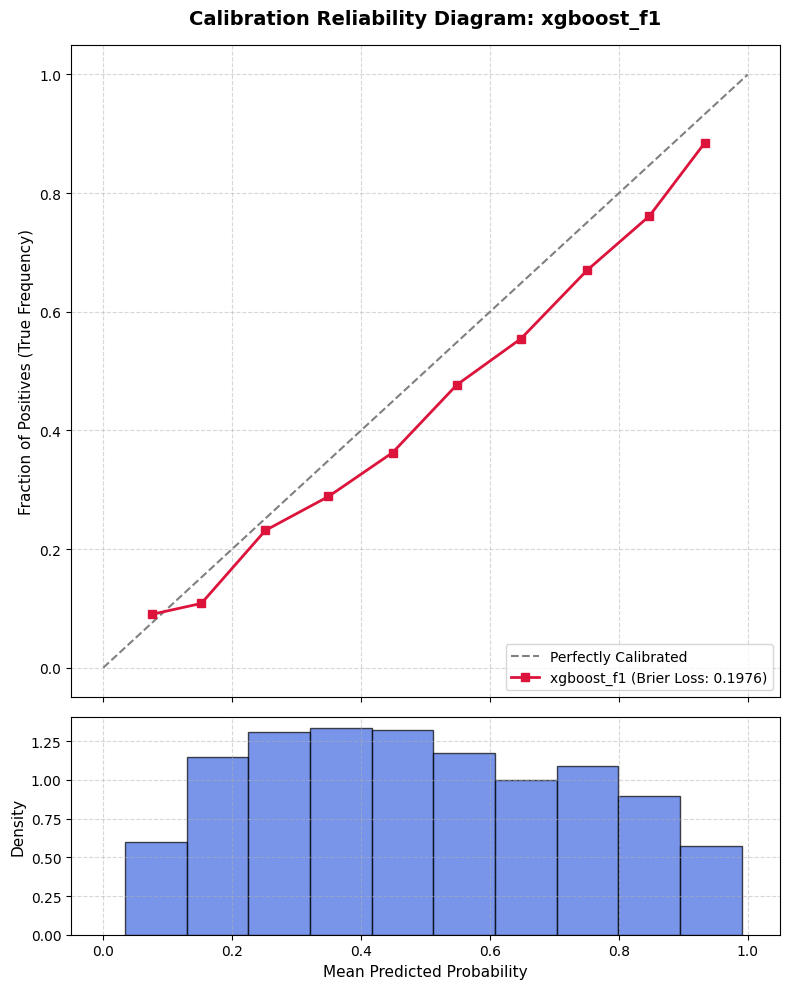

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


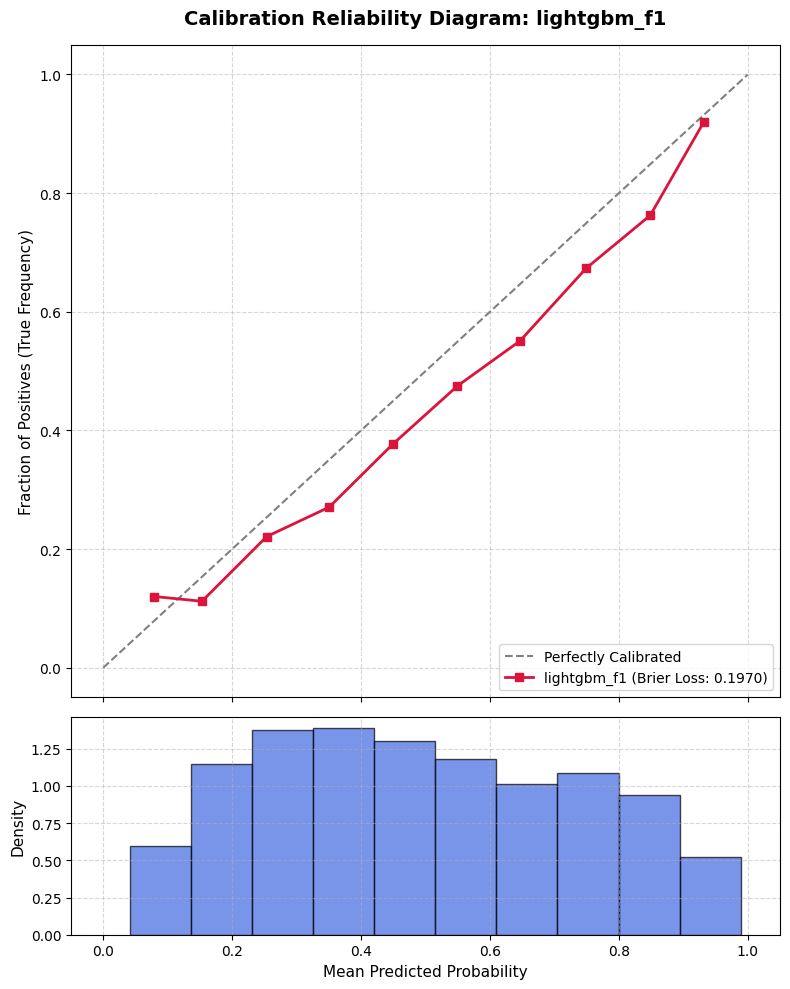

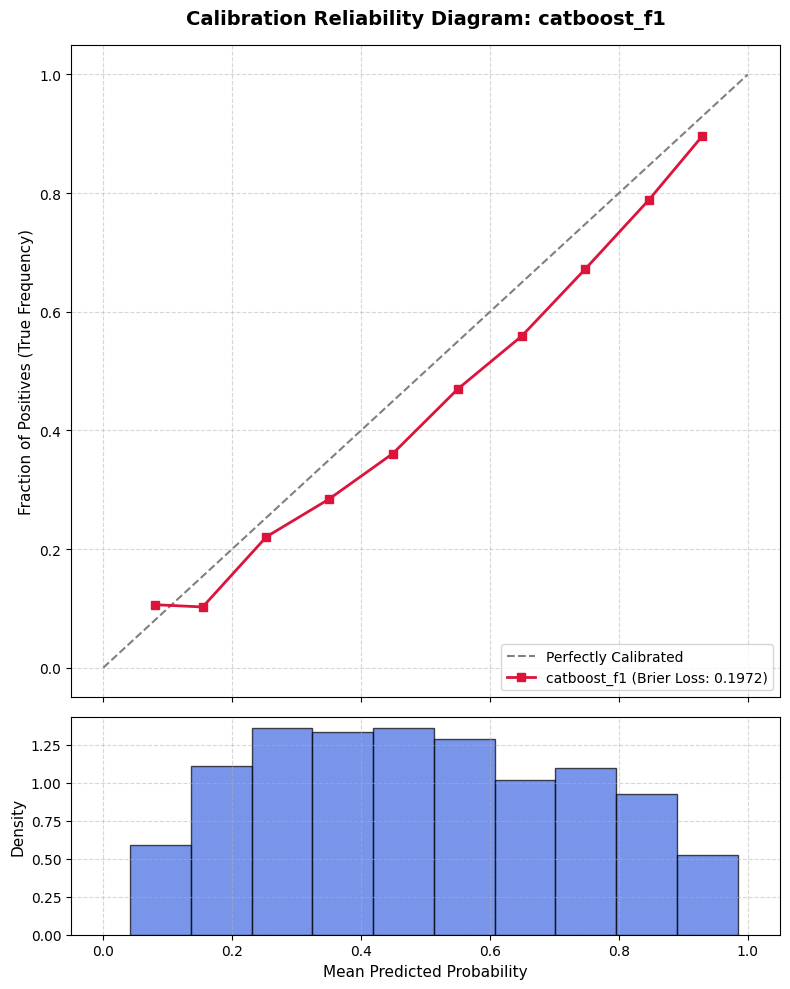

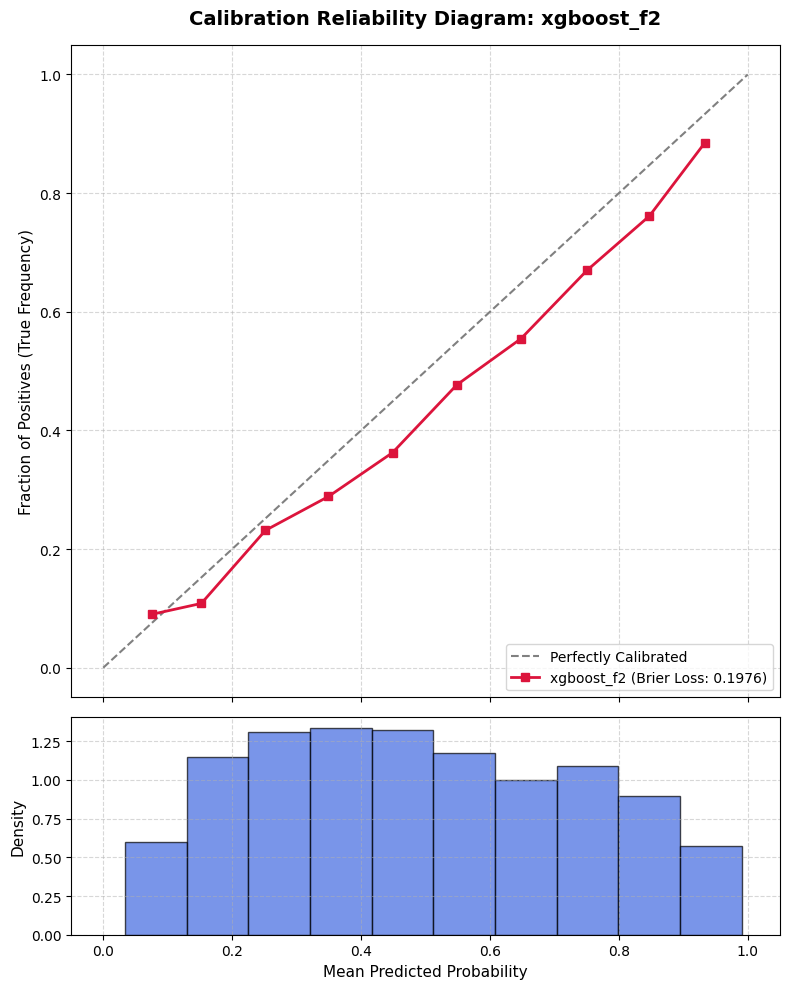

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


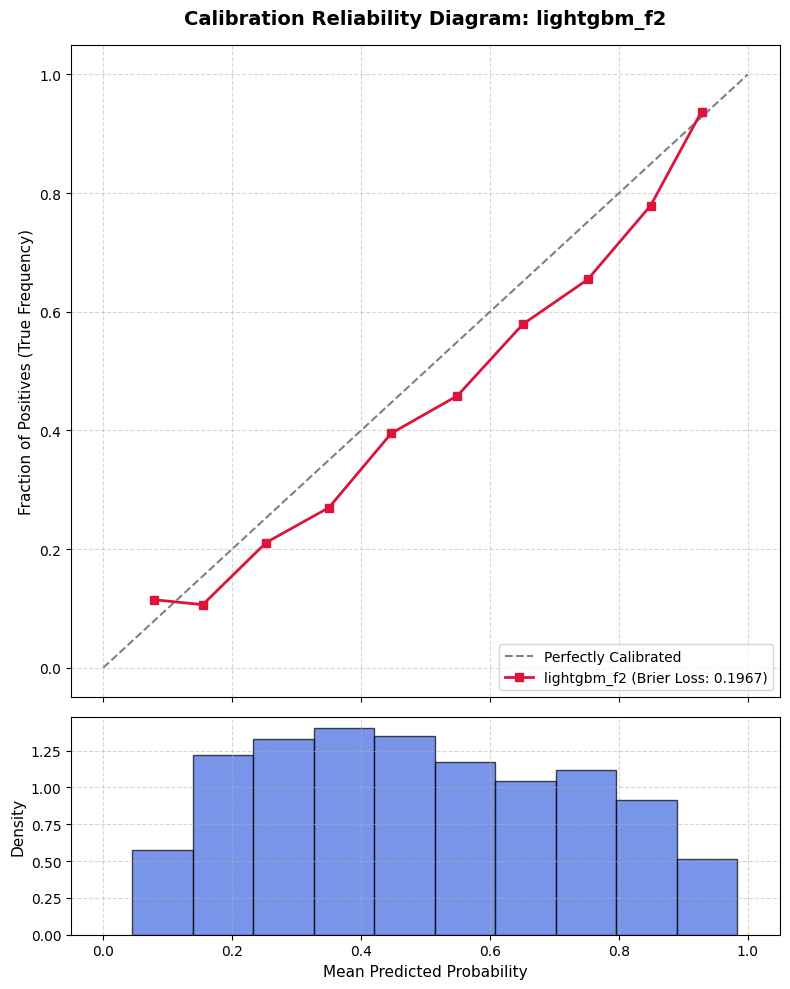

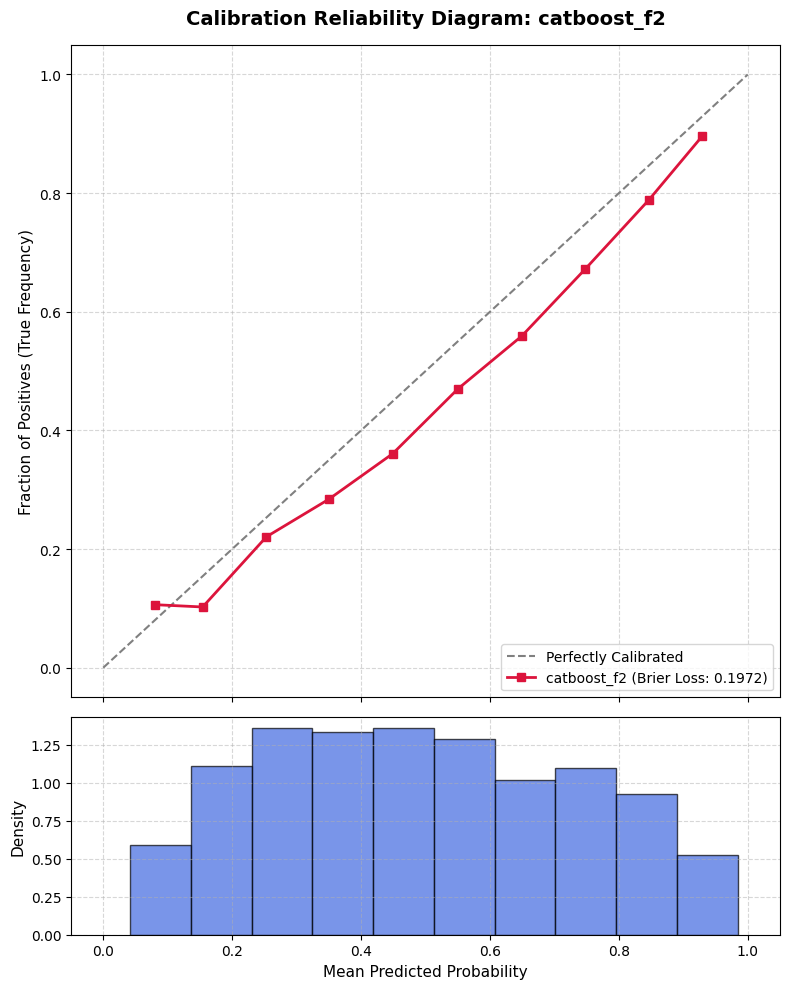

In [ ]:
X_train = df_train[[col for col in df_train.columns if col != 'shd_moderate_or_greater_flag']]
y_train = df_train['shd_moderate_or_greater_flag']
X_val = df_val[[col for col in df_val.columns if col != 'shd_moderate_or_greater_flag']]
y_val = df_val['shd_moderate_or_greater_flag']

for model, name in zip(
    [xgboost_f1, lightgbm_f1, catboost_f1, xgboost_f2, lightgbm_f2, catboost_f2],
    ["xgboost_f1", "lightgbm_f1", "catboost_f1", "xgboost_f2", "lightgbm_f2", "catboost_f2"]
):
    plot_model_calibration(model, X_train, y_train, X_val, y_val, model_name=name)

In [ ]:
from sklearn.isotonic import IsotonicRegression

calibrated_models = {}
model_list = [xgboost_f1, lightgbm_f1, catboost_f1, xgboost_f2, lightgbm_f2, catboost_f2]
model_names = ["xgboost_f1", "lightgbm_f1", "catboost_f1", "xgboost_f2", "lightgbm_f2", "catboost_f2"]

for model, name in zip(model_list, model_names):
    val_probs = model.predict_proba(X_val)[:, 1]
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(val_probs, y_val)
    calibrated_models[name] = {
        'model': model,
        'calibrator': calibrator
    }
    print(f"✓ Calibrated {name}")

print("\n" + "="*80)
print("All models calibrated successfully!")

✓ Calibrated xgboost_f1
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
✓ Calibrated lightgbm_f1
✓ Calibrated catboost_f1
✓ Calibrated xgboost_f2
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
✓ Calibrated lightgbm_f2
✓ Calibrated catboost_f2

All models calibrated successfully!


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


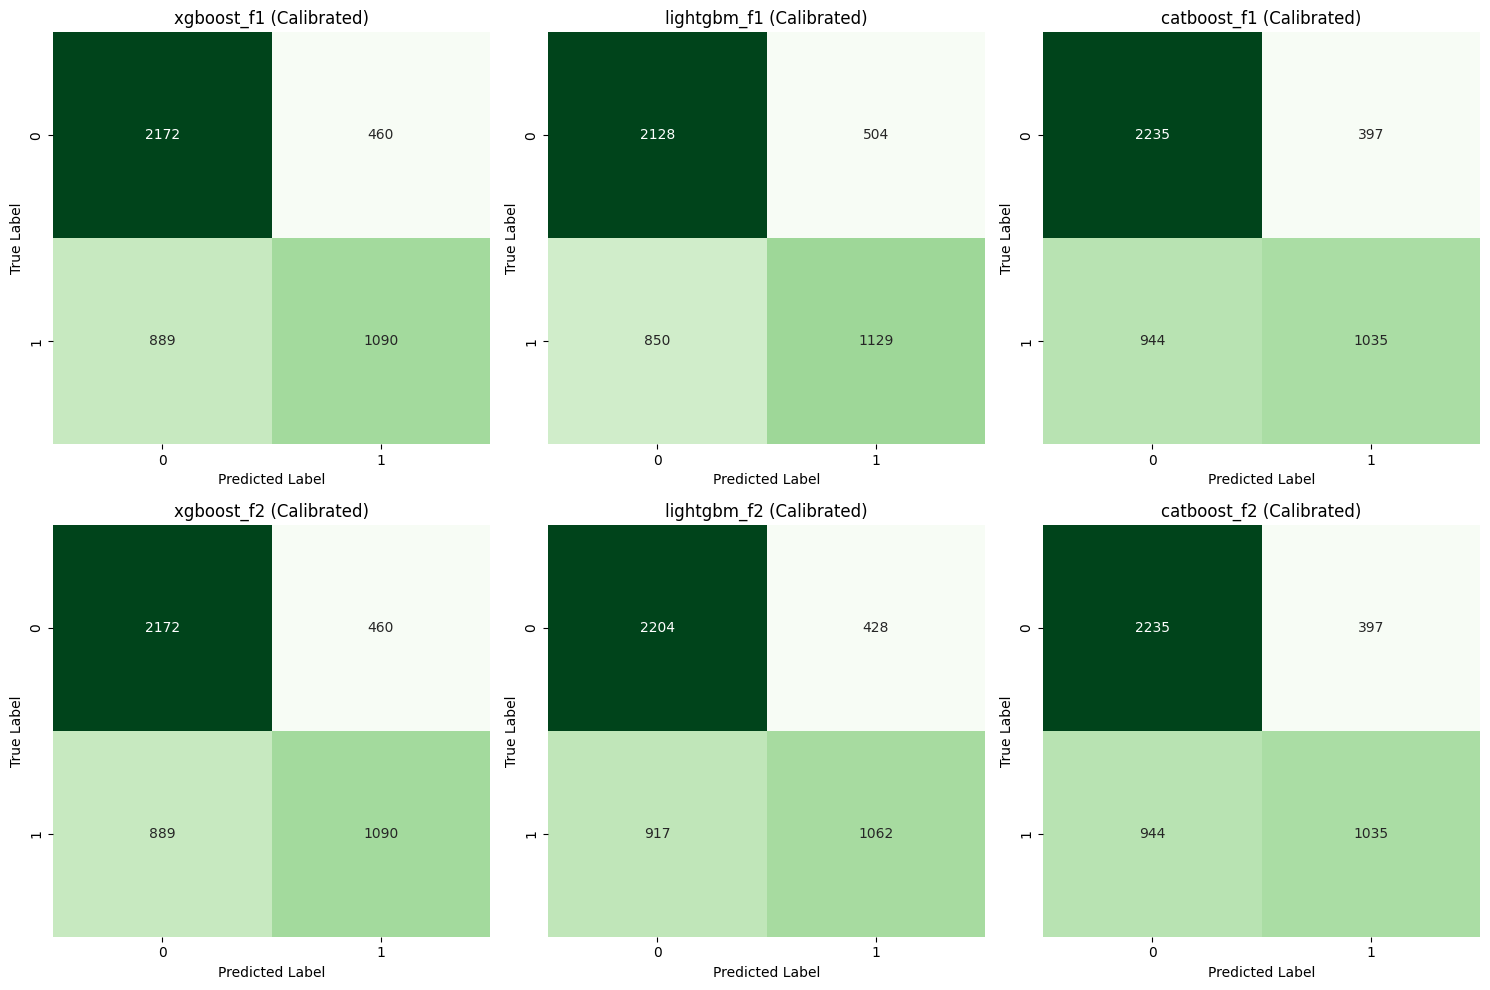


CALIBRATED MODELS - EVALUATION METRICS
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
      Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
 xgboost_f1  0.707439   0.703226 0.550783  0.617739 0.769381
lightgbm_f1  0.706354   0.691366 0.570490  0.625138 0.770705
catboost_f1  0.709174   0.722765 0.522991  0.606860 0.770378
 xgboost_f2  0.707439   0.7032

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, name in enumerate(model_names):
    model = calibrated_models[name]['model']
    calibrator = calibrated_models[name]['calibrator']
    
    raw_probs = model.predict_proba(X_val)[:, 1]
    calibrated_probs = calibrator.predict(raw_probs)
    y_pred_calibrated = (calibrated_probs >= 0.5).astype(int)
    
    cm = confusion_matrix(y_val, y_pred_calibrated)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name} (Calibrated)')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CALIBRATED MODELS - EVALUATION METRICS")
print("="*80)

calibrated_metrics_data = []

for name in model_names:
    model = calibrated_models[name]['model']
    calibrator = calibrated_models[name]['calibrator']
    
    raw_probs = model.predict_proba(X_val)[:, 1]
    calibrated_probs = calibrator.predict(raw_probs)
    y_pred_calibrated = (calibrated_probs >= 0.5).astype(int)
    
    calibrated_metrics_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred_calibrated),
        'Precision': precision_score(y_val, y_pred_calibrated),
        'Recall': recall_score(y_val, y_pred_calibrated),
        'F1 Score': f1_score(y_val, y_pred_calibrated),
        'ROC-AUC': roc_auc_score(y_val, calibrated_probs)
    })

calibrated_metrics_df = pd.DataFrame(calibrated_metrics_data)
print(calibrated_metrics_df.to_string(index=False))
print("="*80)


Plotting calibration curves for calibrated models...



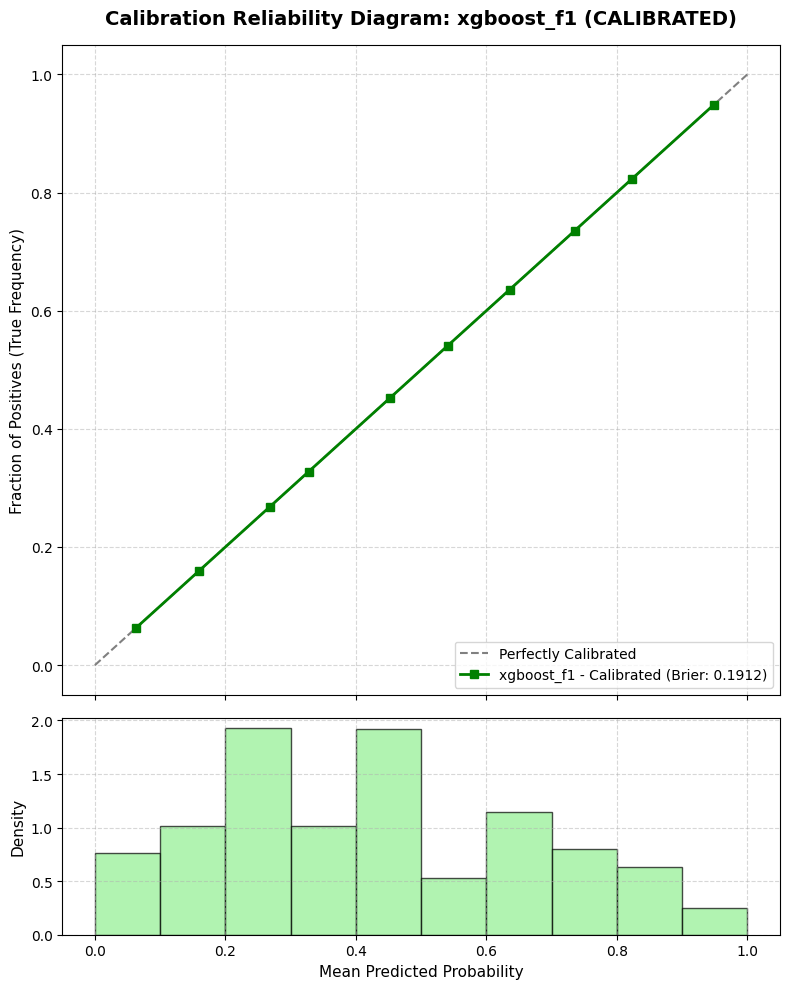

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


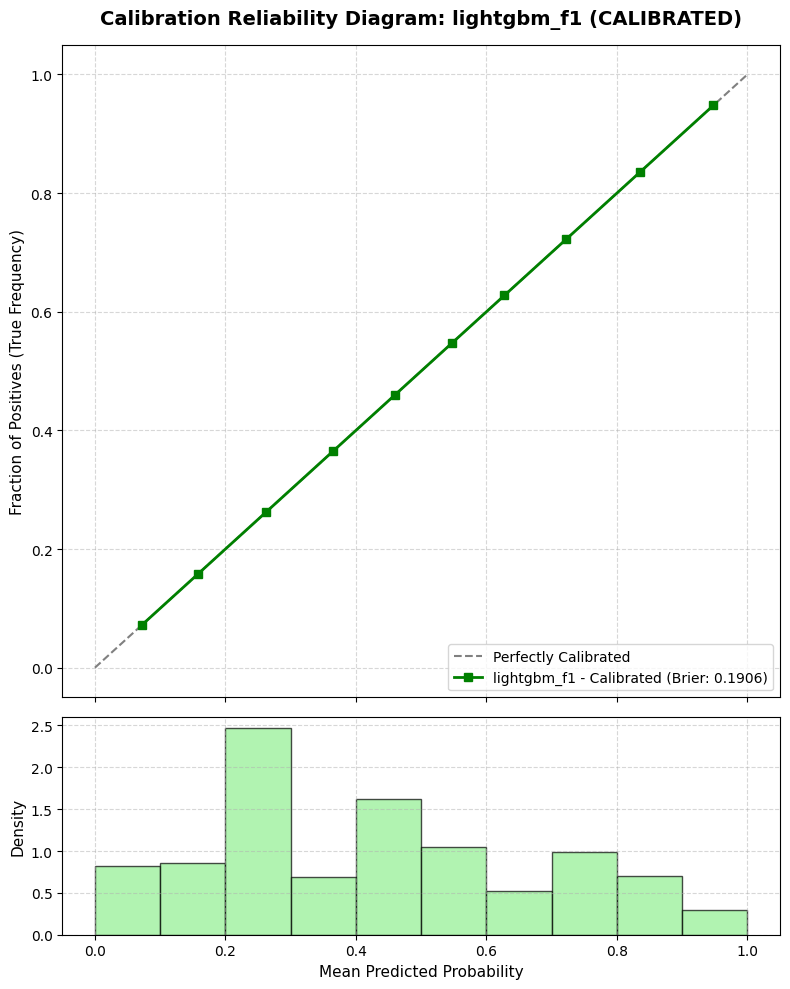

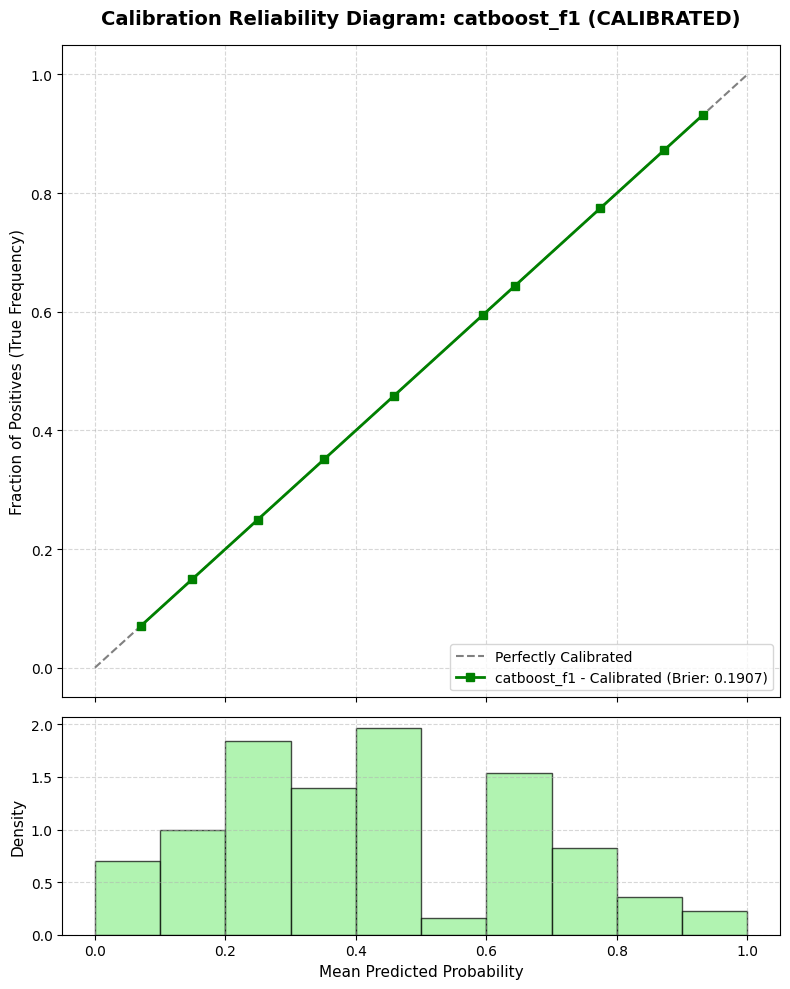

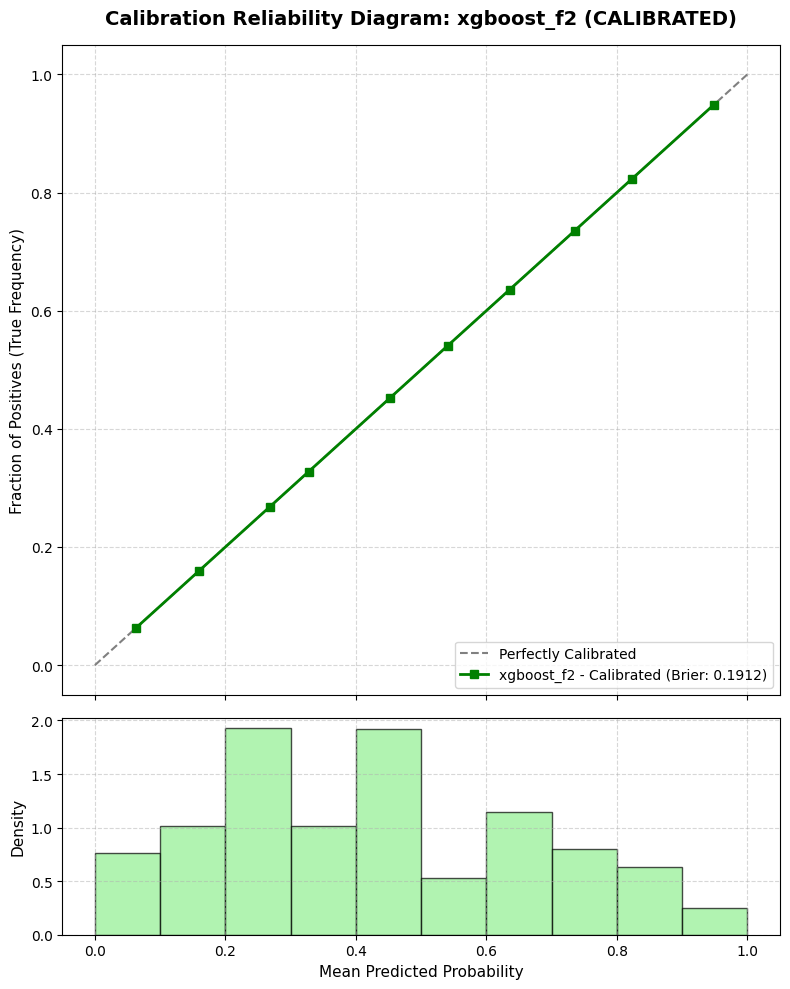

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


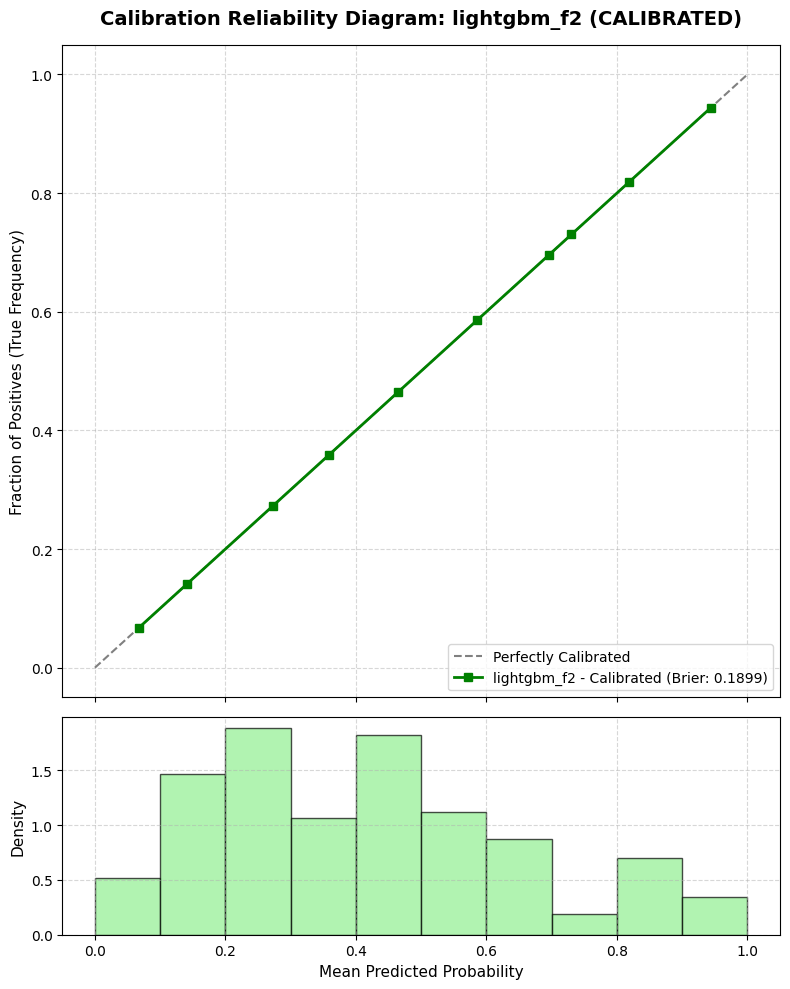

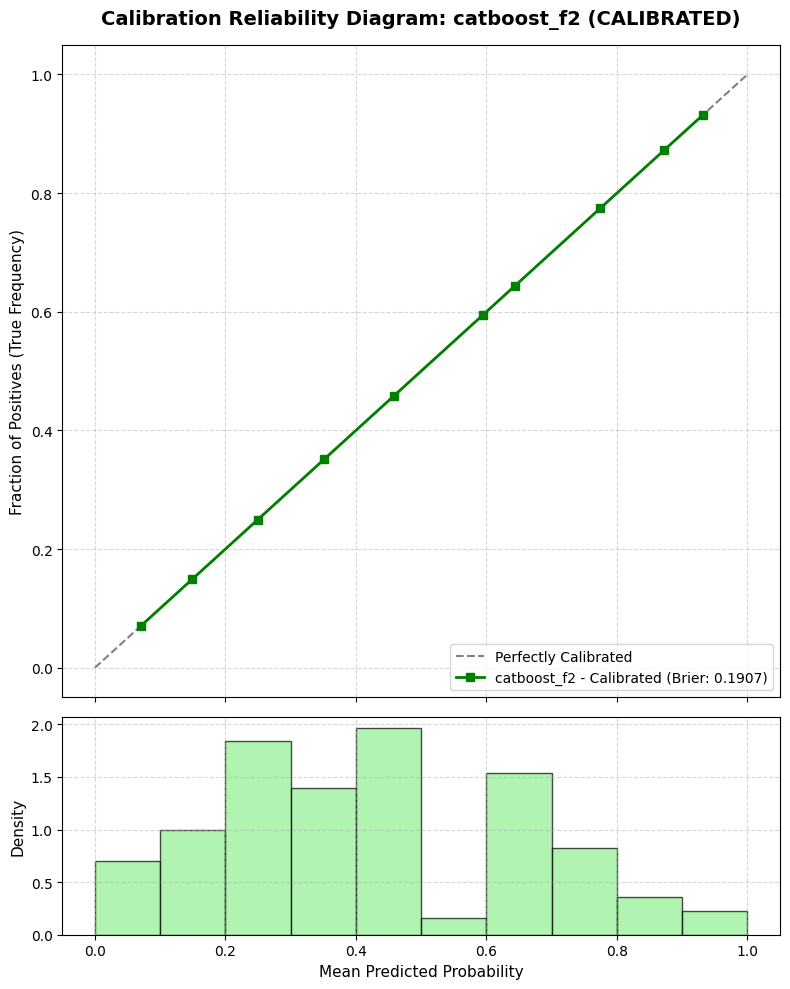

In [ ]:
print("\nPlotting calibration curves for calibrated models...\n")

for name in model_names:
    model = calibrated_models[name]['model']
    calibrator = calibrated_models[name]['calibrator']
    
    raw_probs = model.predict_proba(X_val)[:, 1]
    calibrated_probs = calibrator.predict(raw_probs)
    
    prob_true, prob_pred = calibration_curve(y_val, calibrated_probs, n_bins=10, strategy='uniform')
    brier_score = brier_score_loss(y_val, calibrated_probs)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    ax1.plot(prob_pred, prob_true, marker='s', linestyle='-', color='green', 
             linewidth=2, label=f'{name} - Calibrated (Brier: {brier_score:.4f})')
    ax1.set_ylabel('Fraction of Positives (True Frequency)', fontsize=11)
    ax1.set_title(f'Calibration Reliability Diagram: {name} (CALIBRATED)', fontsize=14, fontweight='bold', pad=15)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.hist(calibrated_probs, bins=10, color='lightgreen', edgecolor='black', alpha=0.7, density=True)
    ax2.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax2.set_ylabel('Density', fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import joblib

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

print("Saving original models...")
for model, name in zip(model_list, model_names):
    joblib.dump(model, os.path.join(models_dir, f"{name}_original.joblib"))
    print(f"✓ Saved {name}_original.joblib")

print("\nSaving calibrated models...")
for name in model_names:
    cal_data = calibrated_models[name]
    joblib.dump(cal_data, os.path.join(models_dir, f"{name}_calibrated.joblib"))
    print(f"✓ Saved {name}_calibrated.joblib")

print("\n" + "="*80)
print(f"All models saved to: {models_dir}/")

Saving original models...
✓ Saved xgboost_f1_original.joblib
✓ Saved lightgbm_f1_original.joblib
✓ Saved catboost_f1_original.joblib
✓ Saved xgboost_f2_original.joblib
✓ Saved lightgbm_f2_original.joblib
✓ Saved catboost_f2_original.joblib

Saving calibrated models...
✓ Saved xgboost_f1_calibrated.joblib
✓ Saved lightgbm_f1_calibrated.joblib
✓ Saved catboost_f1_calibrated.joblib
✓ Saved xgboost_f2_calibrated.joblib
✓ Saved lightgbm_f2_calibrated.joblib
✓ Saved catboost_f2_calibrated.joblib

All models saved to: ../models/


THRESHOLD OPTIMIZATION FOR CALIBRATED MODELS
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


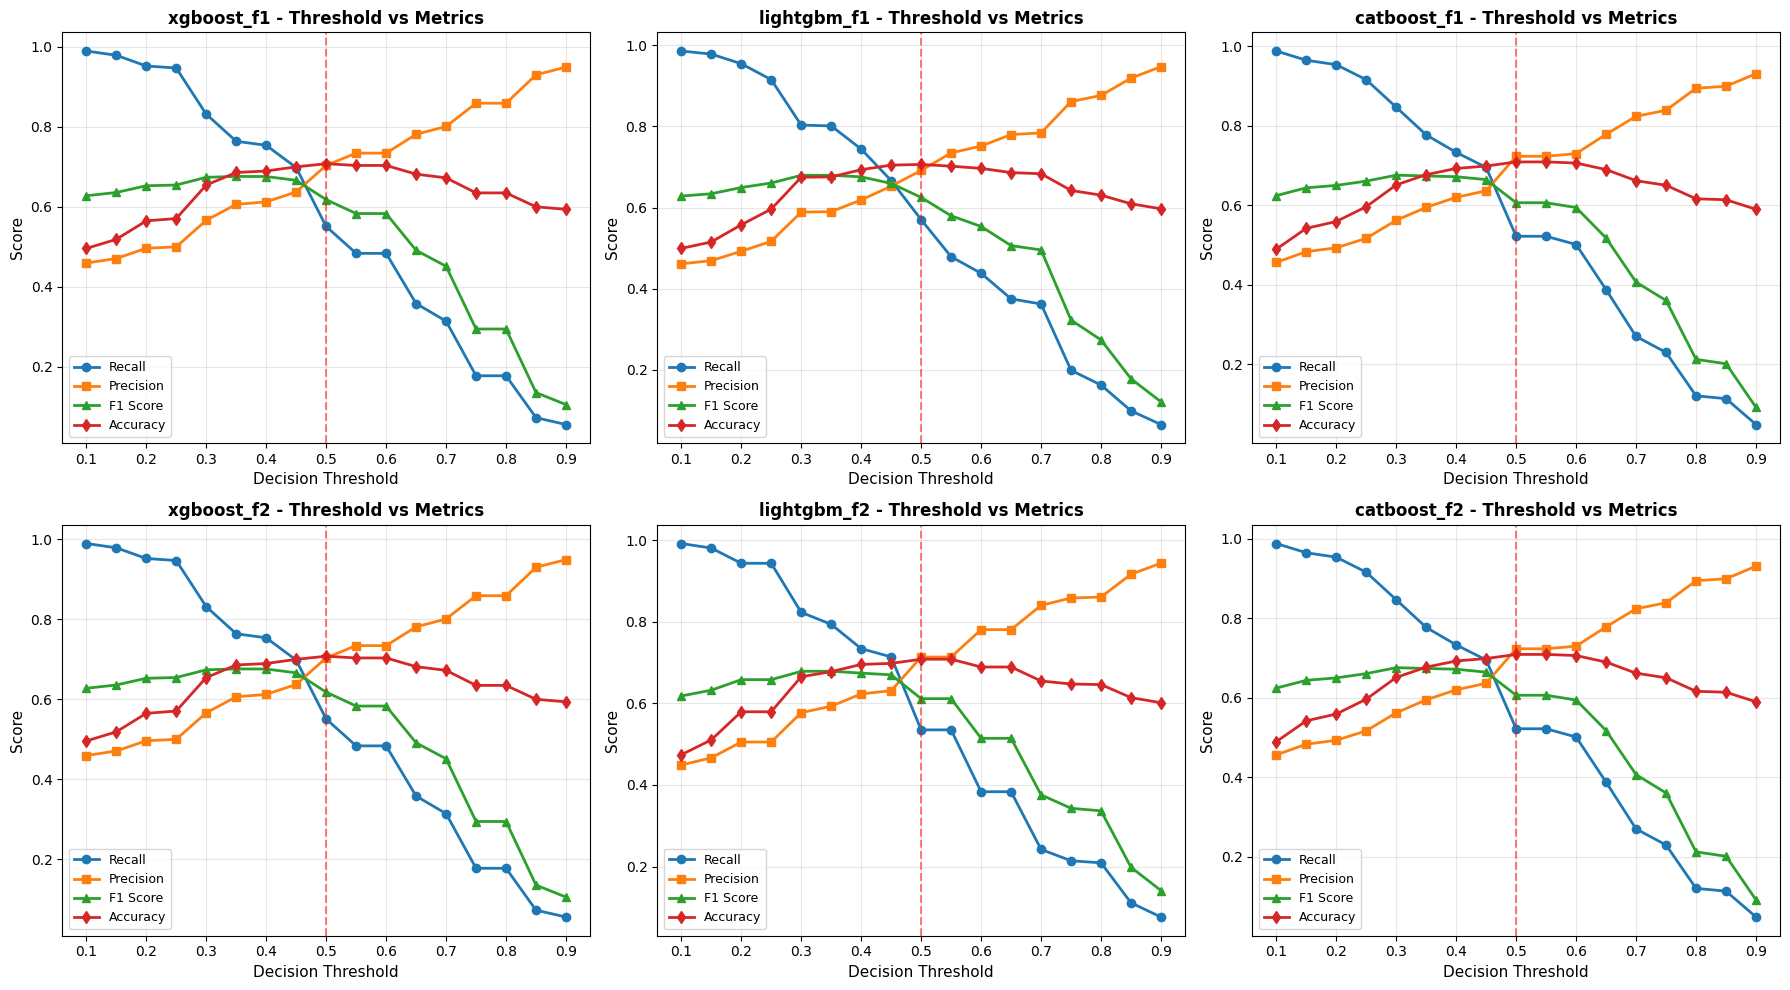


OPTIMAL THRESHOLDS - Highest Precision with Lowest Recall (Recall ≥ 0.80)


,Model,Optimal_Threshold,Recall,Precision,F1_Score,Accuracy
0,xgboost_f1,0.30,0.831228,0.566070,0.673490,0.654088
1,lightgbm_f1,0.35,0.801415,0.589810,0.679520,0.675558
2,catboost_f1,0.30,0.846892,0.562227,0.675806,0.651269
3,xgboost_f2,0.30,0.831228,0.566070,0.673490,0.654088
4,lightgbm_f2,0.30,0.823143,0.577250,0.678609,0.665365
5,catboost_f2,0.30,0.846892,0.562227,0.675806,0.651269


In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve

thresholds_to_test = np.arange(0.1, 0.95, 0.05)
threshold_results = {}

print("="*80)
print("THRESHOLD OPTIMIZATION FOR CALIBRATED MODELS")
print("="*80)

for name in model_names:
    model = calibrated_models[name]['model']
    calibrator = calibrated_models[name]['calibrator']
    
    raw_probs = model.predict_proba(X_val)[:, 1]
    calibrated_probs = calibrator.predict(raw_probs)
    
    threshold_data = []
    
    for threshold in thresholds_to_test:
        y_pred = (calibrated_probs >= threshold).astype(int)
        
        threshold_data.append({
            'Threshold': threshold,
            'Accuracy': accuracy_score(y_val, y_pred),
            'Precision': precision_score(y_val, y_pred, zero_division=0),
            'Recall': recall_score(y_val, y_pred, zero_division=0),
            'F1': f1_score(y_val, y_pred, zero_division=0),
        })
    
    threshold_results[name] = pd.DataFrame(threshold_data)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, name in enumerate(model_names):
    df_thresh = threshold_results[name]
    
    axes[idx].plot(df_thresh['Threshold'], df_thresh['Recall'], marker='o', label='Recall', linewidth=2)
    axes[idx].plot(df_thresh['Threshold'], df_thresh['Precision'], marker='s', label='Precision', linewidth=2)
    axes[idx].plot(df_thresh['Threshold'], df_thresh['F1'], marker='^', label='F1 Score', linewidth=2)
    axes[idx].plot(df_thresh['Threshold'], df_thresh['Accuracy'], marker='d', label='Accuracy', linewidth=2)
    
    axes[idx].set_xlabel('Decision Threshold', fontsize=11)
    axes[idx].set_ylabel('Score', fontsize=11)
    axes[idx].set_title(f'{name} - Threshold vs Metrics', fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')

plt.tight_layout()
plt.show()

best_thresholds_data = []

for name in model_names:
    df_thresh = threshold_results[name]
    high_recall = df_thresh[df_thresh['Recall'] >= 0.80]
    if len(high_recall) > 0:
        best_row = high_recall.sort_values(by=['Precision', 'Recall'], ascending=[False, True]).iloc[0]
        best_thresholds_data.append({
            'Model': name,
            'Optimal_Threshold': best_row['Threshold'],
            'Recall': best_row['Recall'],
            'Precision': best_row['Precision'],
            'F1_Score': best_row['F1'],
            'Accuracy': best_row['Accuracy']
        })

best_thresholds_df = pd.DataFrame(best_thresholds_data)
print("\n" + "="*80)
print("OPTIMAL THRESHOLDS - Highest Precision with Lowest Recall (Recall ≥ 0.80)")
print("="*80)
best_thresholds_df

In [ ]:
from sklearn.metrics import confusion_matrix

prevalence = 0.025  # 2.5% real-world prevalence
recalibrated_data = []
optimal_thresholds_dict = dict(zip(best_thresholds_df['Model'], best_thresholds_df['Optimal_Threshold']))

for name in model_names:
    optimal_threshold = optimal_thresholds_dict.get(name)
    
    if optimal_threshold is None:
        print(f"Warning: No optimal threshold found for {name}, skipping...")
        continue
    
    model = calibrated_models[name]['model']
    calibrator = calibrated_models[name]['calibrator']
    raw_probs = model.predict_proba(X_val)[:, 1]
    calibrated_probs = calibrator.predict(raw_probs)
    
    y_pred = (calibrated_probs >= optimal_threshold).astype(int)
    y_true = y_val
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    ppv = (sensitivity * prevalence) / (sensitivity * prevalence + (1 - specificity) * (1 - prevalence))
    npv = (specificity * (1 - prevalence)) / ((1 - sensitivity) * prevalence + specificity * (1 - prevalence))
    
    recalibrated_data.append({
        'Model': name,
        'Optimal_Threshold': optimal_threshold,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'PPV @ 2.5% Prev': ppv,
        'NPV @ 2.5% Prev': npv,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })


recalibrated_df = pd.DataFrame(recalibrated_data)

print("\n" + "="*120)
print("           METRICS RECALIBRATED FOR 2.5% REAL-WORLD PREVALENCE (Using Optimal Thresholds)")
print("="*120)
print("\nSensitivity (Recall) = TP/(TP+FN) - % of actual patients correctly identified")
print("Specificity = TN/(TN+FP) - % of healthy people correctly identified")
print("\nPPV @ 2.5% Prev = % of positive predictions that are actually positive in real world")
print("NPV @ 2.5% Prev = % of negative predictions that are actually negative in real world")
print("\n" + "-"*120)
print(recalibrated_df.to_string(index=False))
print("="*120)

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8

           METRICS RECALIBRATED FOR 2.5% REAL-WORLD PREVALENCE (Using Optimal Thresholds)

Sensitivity (Recall) = TP/(TP+FN) - % of actual patients correctly identified
Specificity = TN/(TN+FP) - % of healthy people correctly identified

PPV @ 2.5% Prev = % of positive predictions that are actually positive in r

In [9]:
df_test = pd.read_csv("../processed_data/test_features_standardized.csv")
df_test = df_test.drop(columns=[col for col in df_test.columns if 'flag' in col.lower() and col != 'shd_moderate_or_greater_flag'])
df_test = df_test.dropna(subset=ecg_feature_cols, how='all')

X_test = df_test[[col for col in df_test.columns if col != 'shd_moderate_or_greater_flag']]
y_test = df_test['shd_moderate_or_greater_flag']

In [ ]:
import shap

print("="*80)
print("CALCULATING SHAP VALUES FOR UNCALIBRATED MODELS ON TEST DATA")
print("="*80)

shap_values_dict = {}

for name in model_names:
    print(f"\nCalculating SHAP for {name}...")
    model = calibrated_models[name]['model']
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    shap_values_dict[name] = {
        'explainer': explainer,
        'shap_values': shap_vals,
        'base_value': explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
    }
    print(f"✓ SHAP values computed for {name}")

print("\n" + "="*80)
print("SHAP computation complete!")

CALCULATING SHAP VALUES FOR UNCALIBRATED MODELS ON TEST DATA

Calculating SHAP for xgboost_f1...
✓ SHAP values computed for xgboost_f1

Calculating SHAP for lightgbm_f1...


c:\Users\alicj\Desktop\praca_magisterska_kod\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


✓ SHAP values computed for lightgbm_f1

Calculating SHAP for catboost_f1...
✓ SHAP values computed for catboost_f1

Calculating SHAP for xgboost_f2...
✓ SHAP values computed for xgboost_f2

Calculating SHAP for lightgbm_f2...


c:\Users\alicj\Desktop\praca_magisterska_kod\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


✓ SHAP values computed for lightgbm_f2

Calculating SHAP for catboost_f2...
✓ SHAP values computed for catboost_f2

SHAP computation complete!



PLOTTING SHAP SUMMARY PLOTS

SHAP Summary for xgboost_f1:


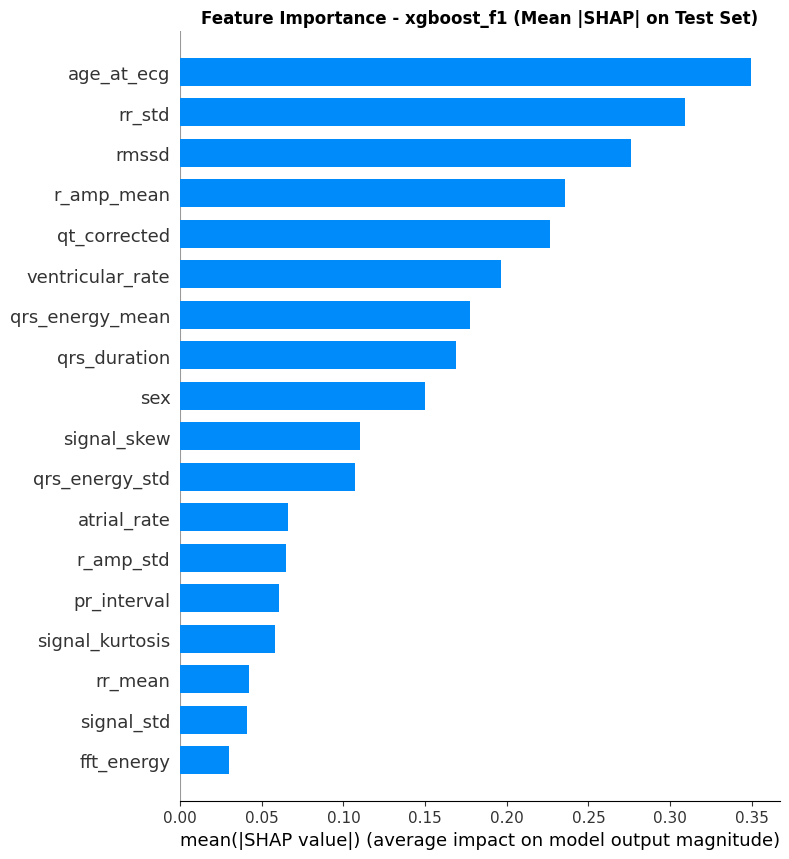

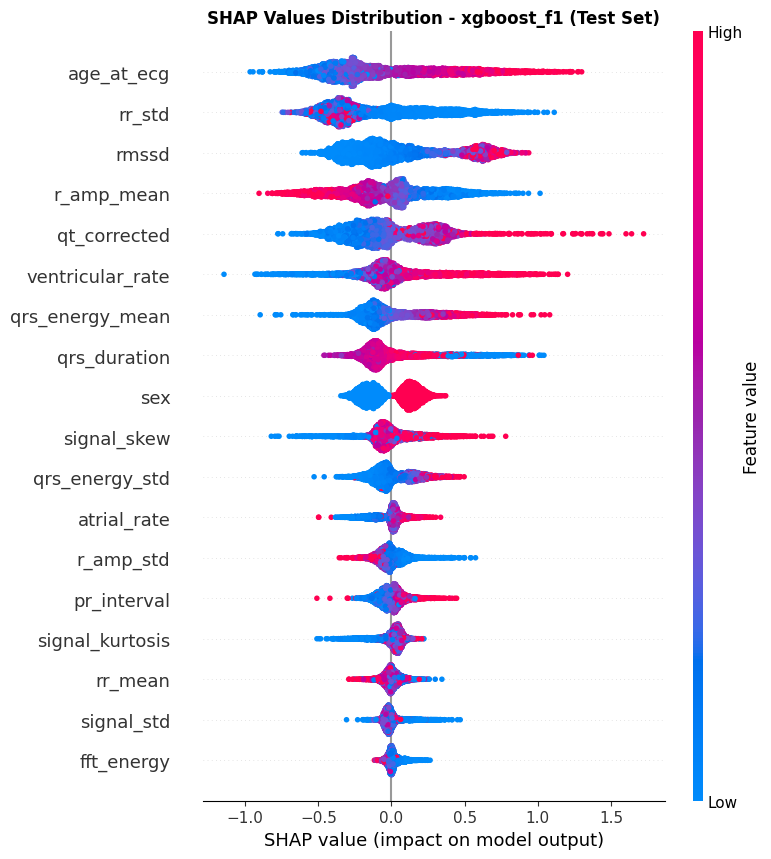

SHAP Summary for lightgbm_f1:


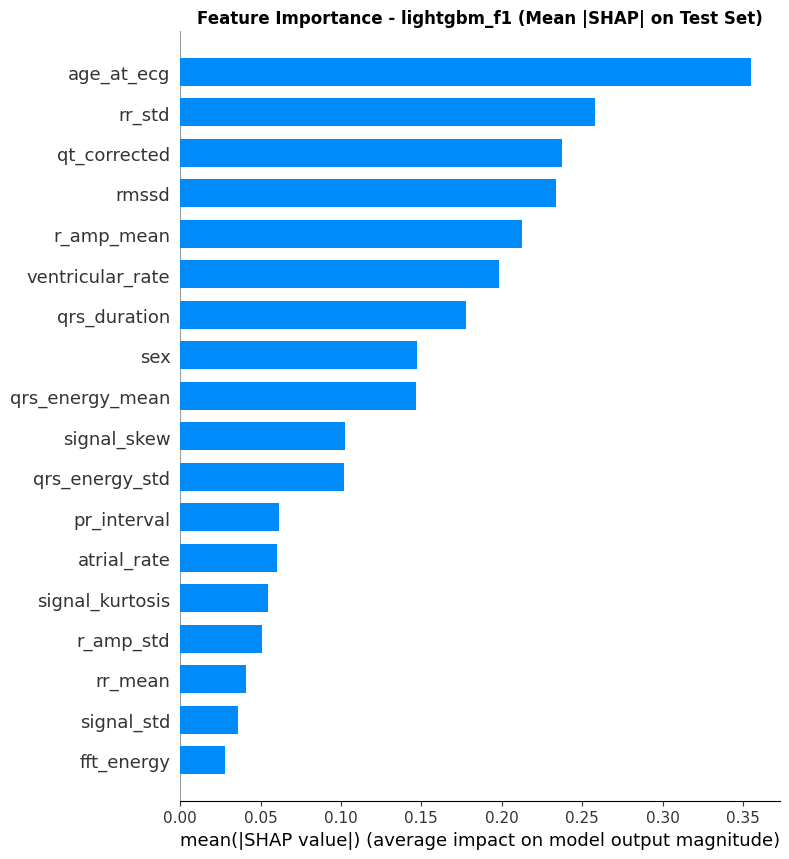

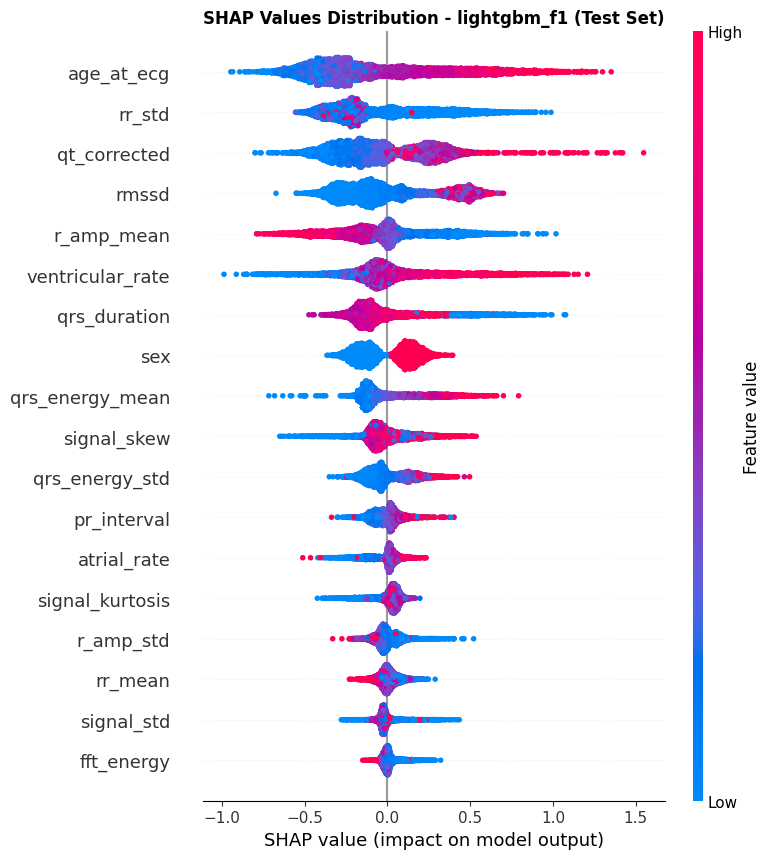

SHAP Summary for catboost_f1:


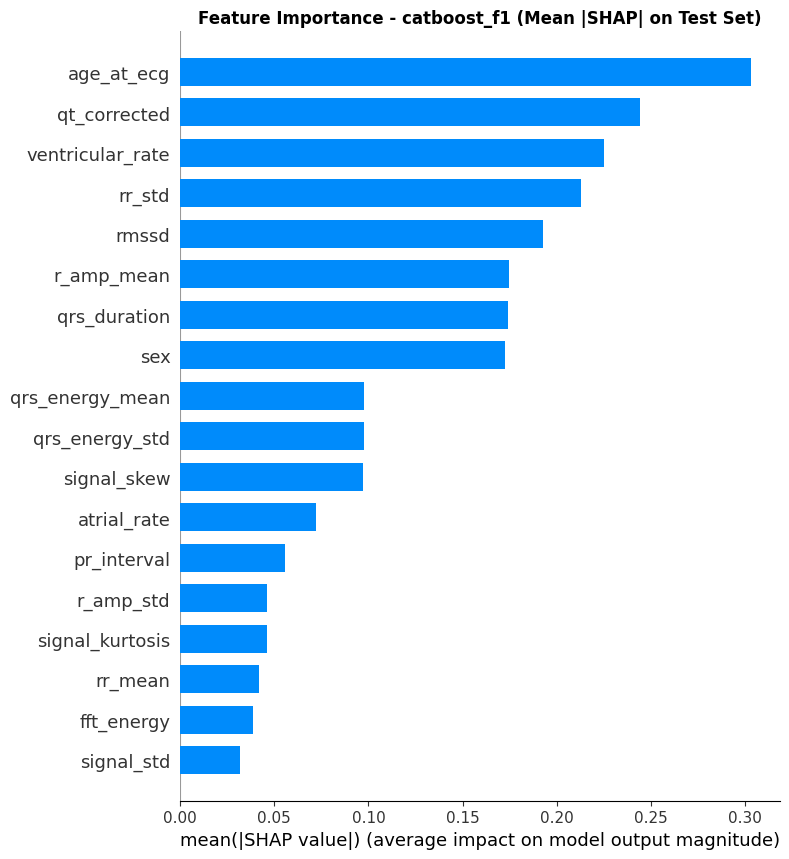

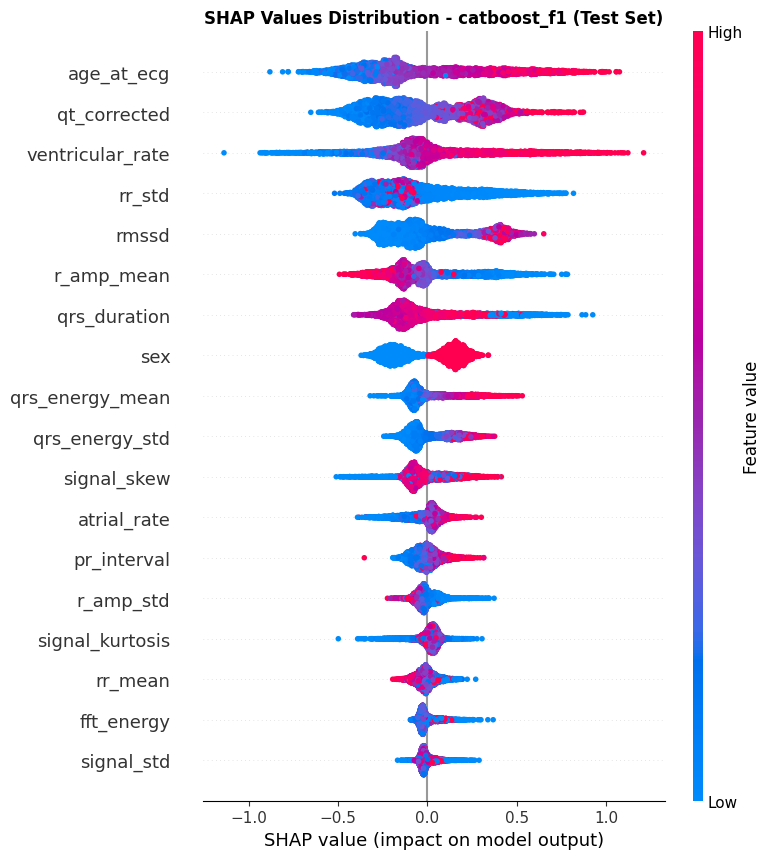

SHAP Summary for xgboost_f2:


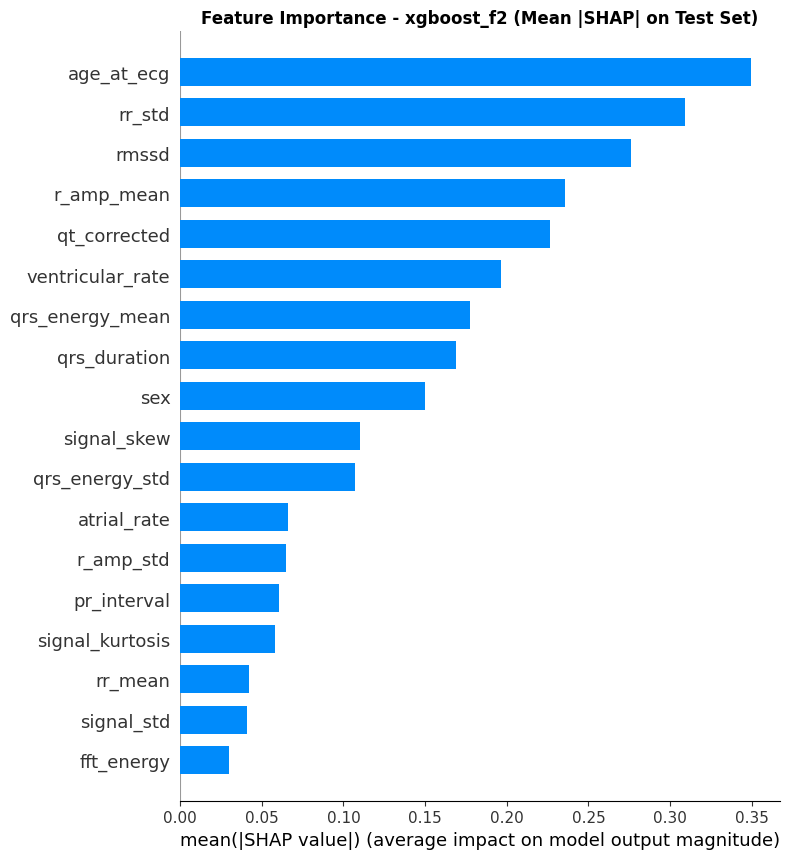

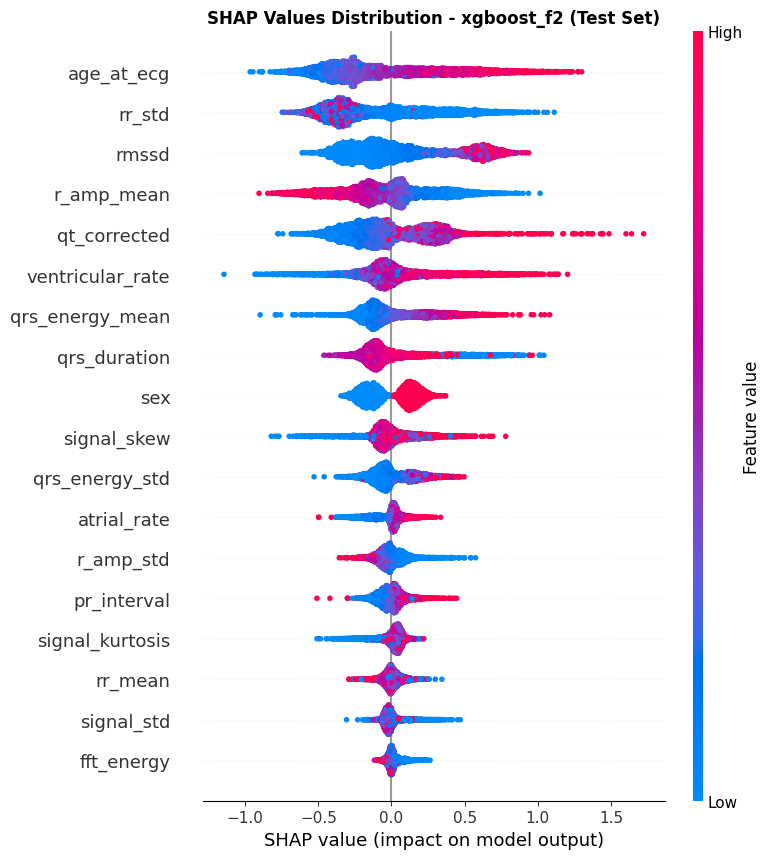

SHAP Summary for lightgbm_f2:


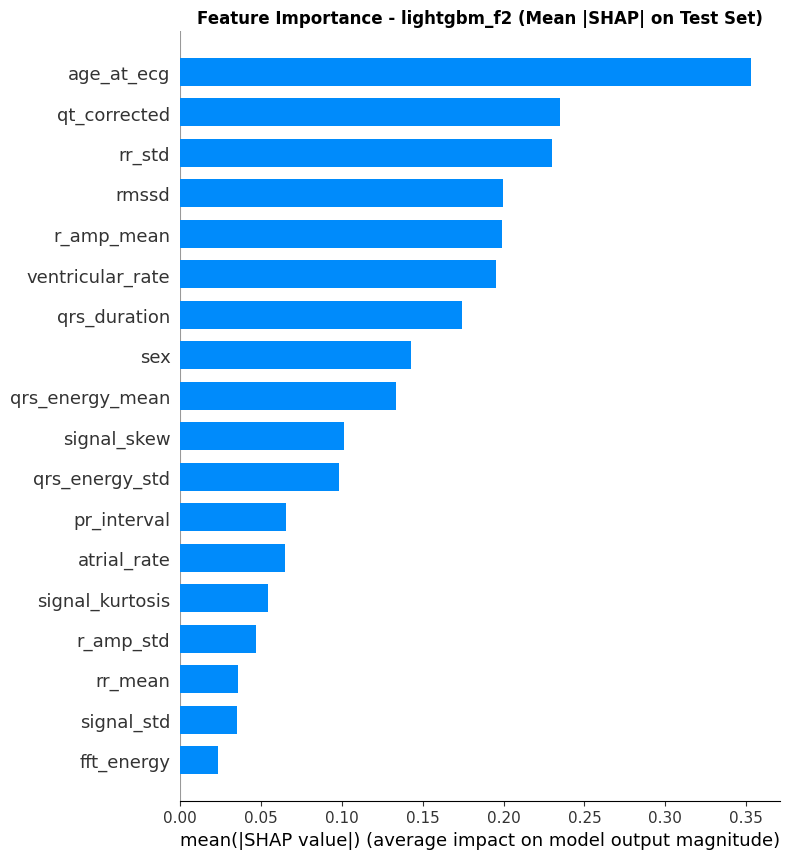

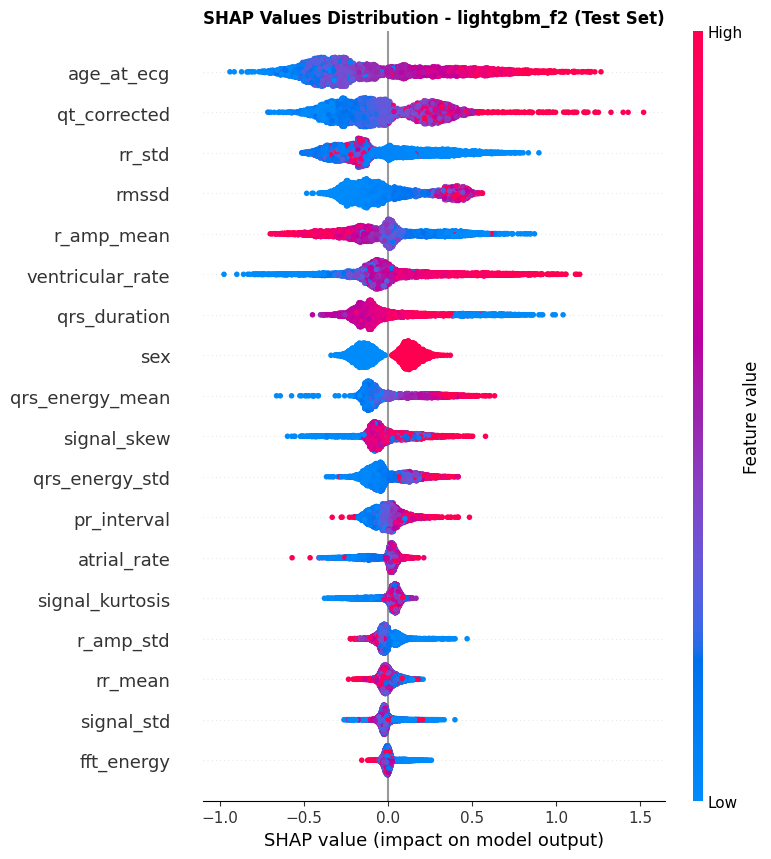

SHAP Summary for catboost_f2:


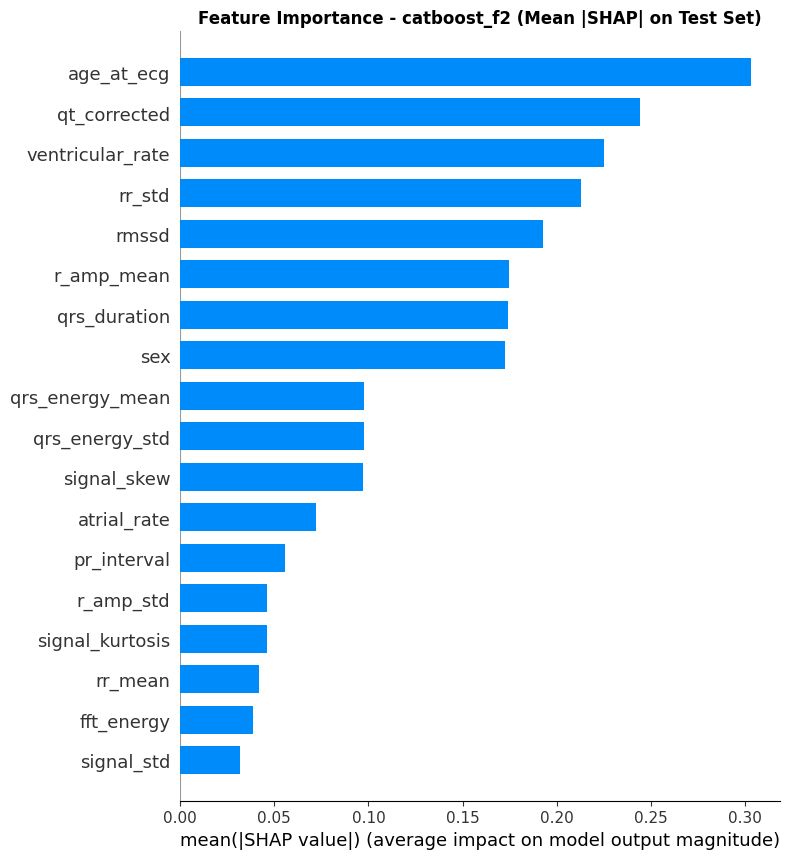

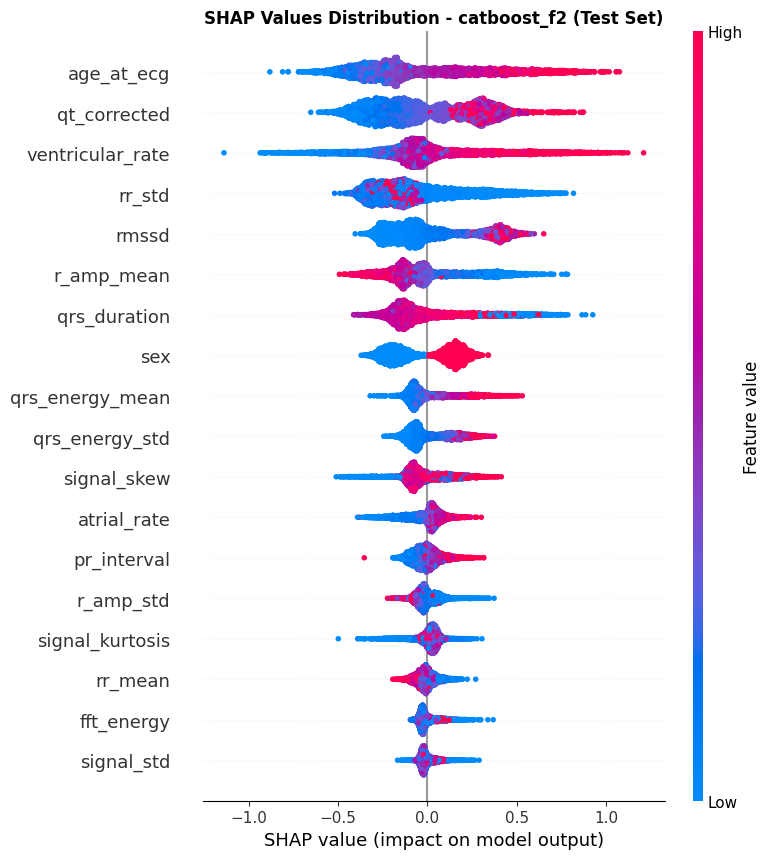


SHAP visualization complete!


In [ ]:
print("\n" + "="*80)
print("PLOTTING SHAP SUMMARY PLOTS")
print("="*80 + "\n")

for name in model_names:
    shap_data = shap_values_dict[name]
    shap_vals = shap_data['shap_values']
    
    print(f"SHAP Summary for {name}:")
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test, plot_type="bar", show=False)
    plt.title(f"Feature Importance - {name} (Mean |SHAP| on Test Set)", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test, plot_type="dot", show=False)
    plt.title(f"SHAP Values Distribution - {name} (Test Set)", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("SHAP visualization complete!")

ROC-AUC AND PR-AUC CURVES ON TEST DATA (Per Model)
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


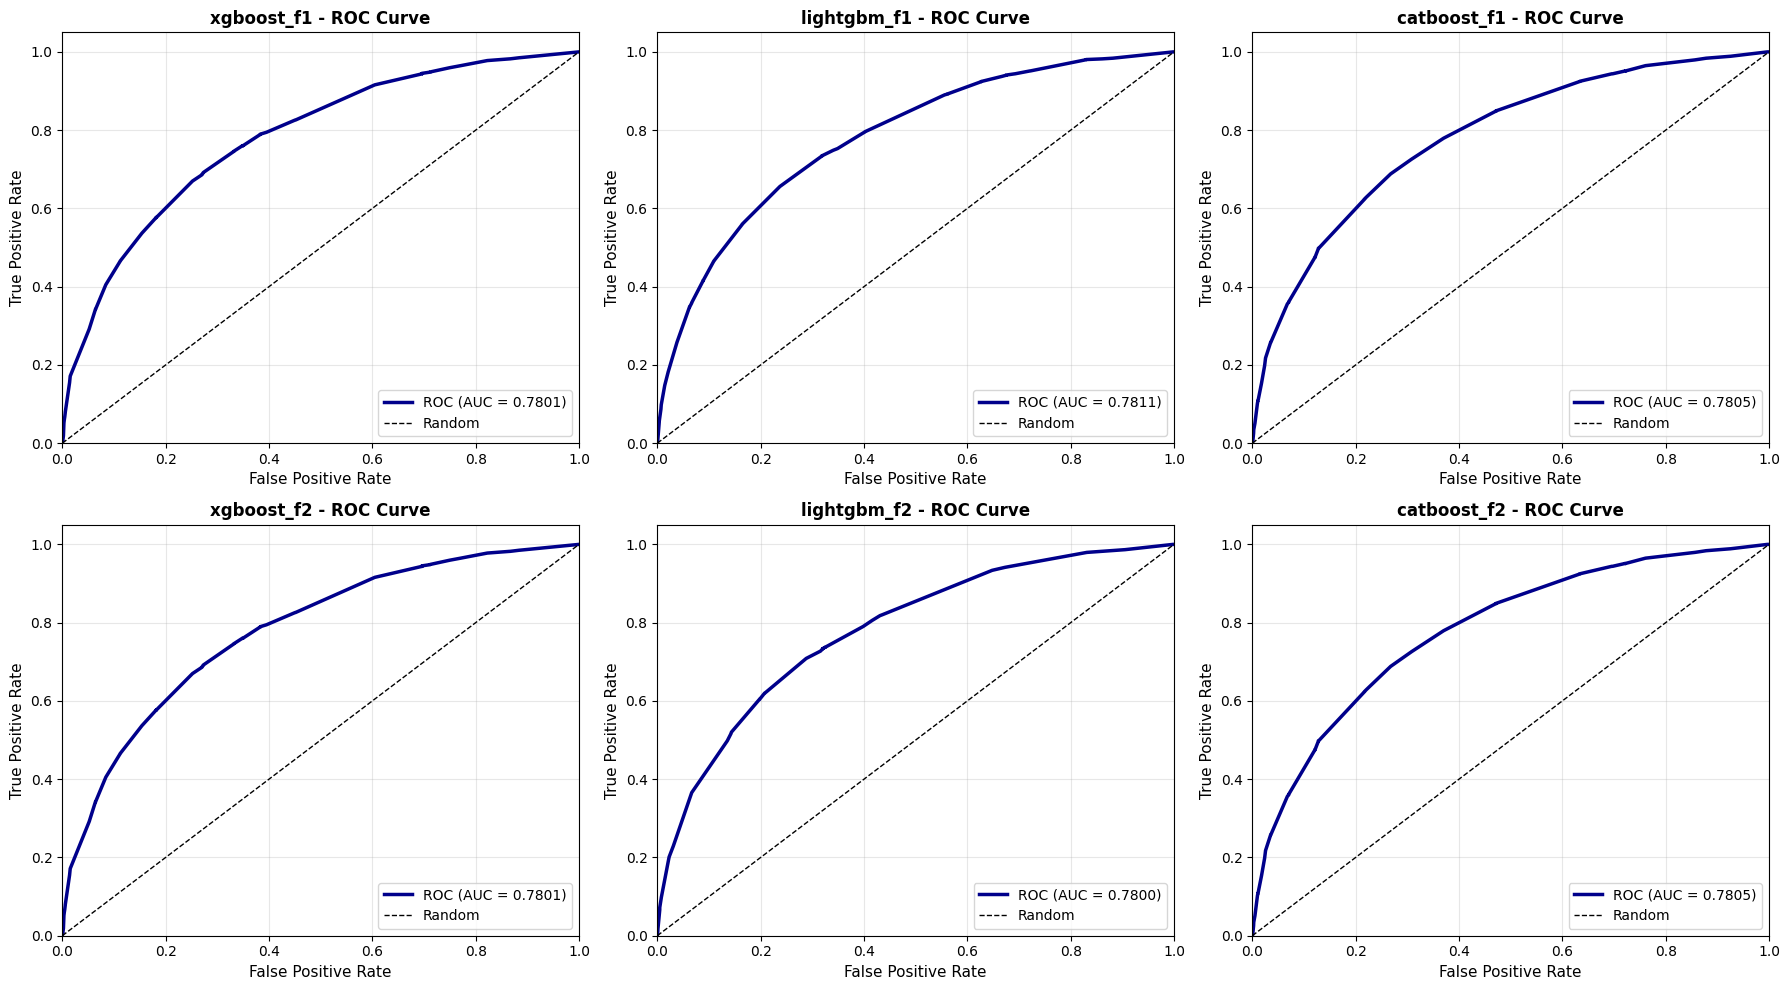

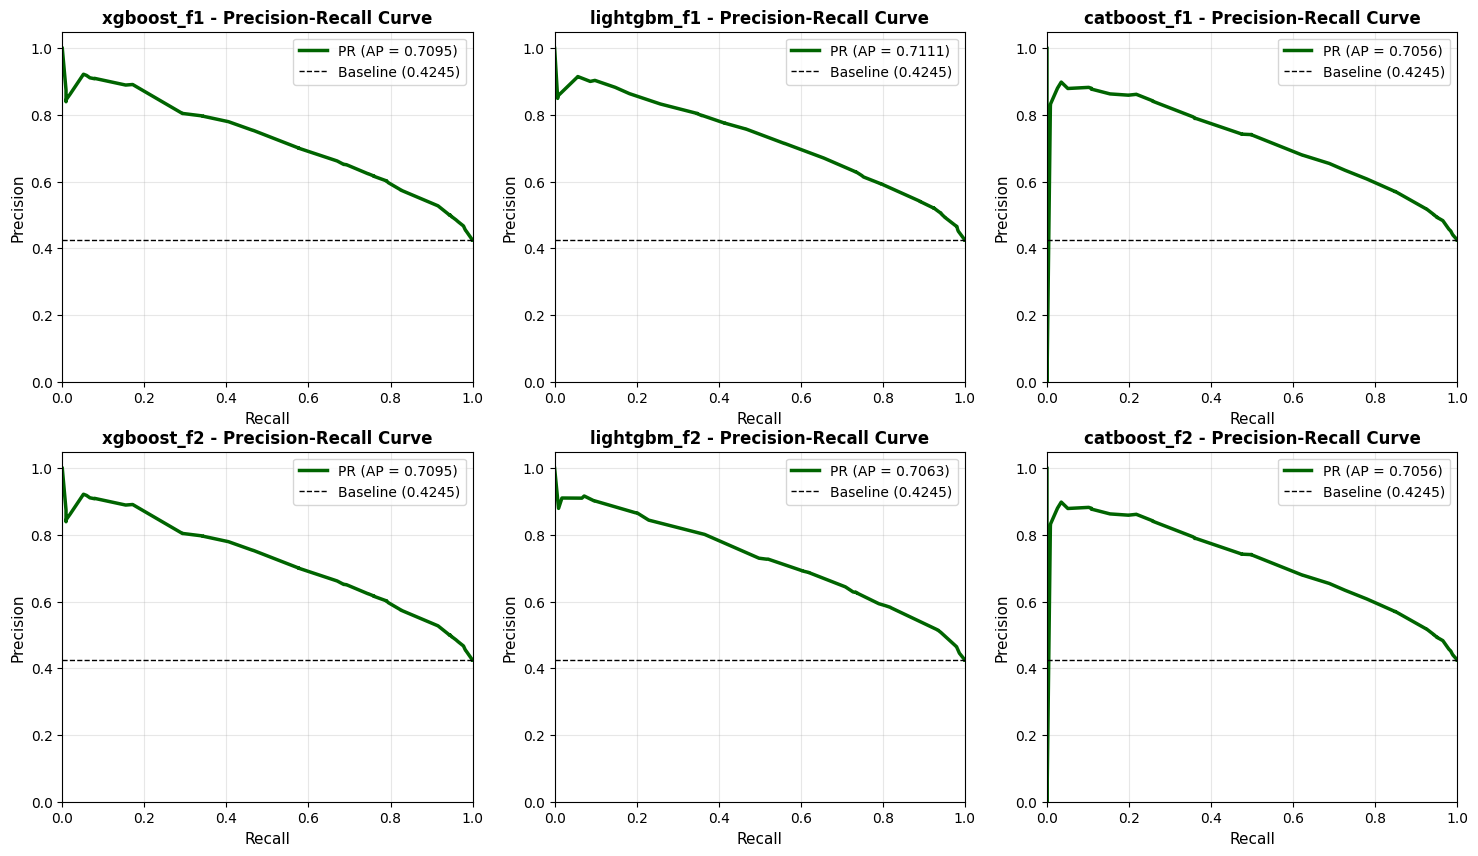


AUC SCORES ON TEST SET (Calibrated Models)
      Model  ROC-AUC   PR-AUC
 xgboost_f1 0.780081 0.709457
lightgbm_f1 0.781089 0.711146
catboost_f1 0.780465 0.705602
 xgboost_f2 0.780081 0.709457
lightgbm_f2 0.780028 0.706253
catboost_f2 0.780465 0.705602


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("="*80)
print("ROC-AUC AND PR-AUC CURVES ON TEST DATA (Per Model)")
print("="*80)

auc_scores = []

fig_roc, axes_roc = plt.subplots(2, 3, figsize=(18, 10))
axes_roc = axes_roc.flatten()
fig_pr, axes_pr = plt.subplots(2, 3, figsize=(18, 10))
axes_pr = axes_pr.flatten()

for idx, name in enumerate(model_names):
    model = calibrated_models[name]['model']
    calibrator = calibrated_models[name]['calibrator']
    
    raw_probs = model.predict_proba(X_test)[:, 1]
    y_pred_proba = calibrator.predict(raw_probs)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    auc_scores.append({
        'Model': name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    axes_roc[idx].plot(fpr, tpr, linewidth=2.5, color='darkblue', label=f'ROC (AUC = {roc_auc:.4f})')
    axes_roc[idx].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    axes_roc[idx].set_xlabel('False Positive Rate', fontsize=11)
    axes_roc[idx].set_ylabel('True Positive Rate', fontsize=11)
    axes_roc[idx].set_title(f'{name} - ROC Curve', fontsize=12, fontweight='bold')
    axes_roc[idx].legend(loc='lower right', fontsize=10)
    axes_roc[idx].grid(True, alpha=0.3)
    axes_roc[idx].set_xlim([0.0, 1.0])
    axes_roc[idx].set_ylim([0.0, 1.05])
    
    axes_pr[idx].plot(recall, precision, linewidth=2.5, color='darkgreen', label=f'PR (AP = {pr_auc:.4f})')
    axes_pr[idx].axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1, label=f'Baseline ({y_test.mean():.4f})')
    axes_pr[idx].set_xlabel('Recall', fontsize=11)
    axes_pr[idx].set_ylabel('Precision', fontsize=11)
    axes_pr[idx].set_title(f'{name} - Precision-Recall Curve', fontsize=12, fontweight='bold')
    axes_pr[idx].legend(loc='best', fontsize=10)
    axes_pr[idx].grid(True, alpha=0.3)
    axes_pr[idx].set_xlim([0.0, 1.0])
    axes_pr[idx].set_ylim([0.0, 1.05])

fig_roc.tight_layout()
plt.show()

fig_pr.tight_layout()
plt.show()

auc_df = pd.DataFrame(auc_scores)
print("\n" + "="*80)
print("AUC SCORES ON TEST SET (Calibrated Models)")
print("="*80)
print(auc_df.to_string(index=False))
print("="*80)

In [10]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    fbeta_score
)
from sklearn.utils import resample

models_dir = "../models"
thresholds = {
    'xgboost_f1': 0.30,
    'lightgbm_f1': 0.35,
    'catboost_f1': 0.30,
    'xgboost_f2': 0.30,
    'lightgbm_f2': 0.30,
    'catboost_f2': 0.30
}
N_RUNS = 2000

def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(
        y_true,
        y_pred
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f2 = fbeta_score(
        y_true,
        y_pred,
        beta=2,
        zero_division=0
    )
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )
    tn, fp, fn, tp = cm.ravel()
    sens = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )
    spec = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )
    ppv = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )
    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )
    return {
        'Accuracy': acc,
        'F1-Score': f1,
        'F2-Score': f2,
        'Sensitivity': sens,
        'Specificity': spec,
        'PPV': ppv,
        'NPV': npv,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    }

def format_result(
    point_estimate,
    ci_lower,
    ci_upper,
    metric
):
    if metric in ['TP', 'TN', 'FP', 'FN']:
        return (
            f"{point_estimate:.1f} "
            f"[{ci_lower:.1f}, {ci_upper:.1f}]"
        )
    return (
        f"{point_estimate:.4f} "
        f"[{ci_lower:.4f}, {ci_upper:.4f}]"
    )

def compute_summary(
    bootstrap_results,
    point_estimates,
    model_name
):
    summary = {
        'Model': model_name
    }
    for metric, values in bootstrap_results.items():
        values = np.asarray(
            values,
            dtype=float
        )
        # 95% percentile bootstrap CI
        ci_lower = np.percentile(
            values,
            2.5
        )
        ci_upper = np.percentile(
            values,
            97.5
        )
        point_estimate = point_estimates[metric]
        summary[metric] = format_result(
            point_estimate,
            ci_lower,
            ci_upper,
            metric
        )
    return summary

model_files = [
    f for f in os.listdir(models_dir)
    if f.endswith("_calibrated.joblib")
]
model_files.sort()
print("Found calibrated models:")
for file in model_files:
    print(f"  - {file}")

results = []
y_test_arr = np.asarray(y_test)
n_samples = len(y_test_arr)

for file_name in model_files:
    name = file_name.replace(
        "_calibrated.joblib",
        ""
    )
    if name not in thresholds:
        print(
            f"\nSkipping {name}: "
            f"no threshold defined."
        )
        continue
    threshold = thresholds[name]
    model_path = os.path.join(
        models_dir,
        file_name
    )

    print(
        f"\nLoading {file_name}..."
    )
    calibrated_data = joblib.load(
        model_path
    )
    model = calibrated_data['model']
    calibrator = calibrated_data['calibrator']

    raw_probs = model.predict_proba(
        X_test
    )[:, 1]
    y_pred_proba = calibrator.predict(
        raw_probs
    )
    y_pred = (
        y_pred_proba >= threshold
    ).astype(int)
    point_estimates = calculate_metrics(
        y_test_arr,
        y_pred
    )
    metrics_bootstrap = {
        'Accuracy': [],
        'F1-Score': [],
        'F2-Score': [],
        'Sensitivity': [],
        'Specificity': [],
        'PPV': [],
        'NPV': [],
        'TP': [],
        'TN': [],
        'FP': [],
        'FN': []
    }

    for seed in range(N_RUNS):
        boot_indices = resample(
            np.arange(n_samples),
            replace=True,
            random_state=seed
        )
        y_true_boot = (
            y_test_arr[boot_indices]
        )
        y_proba_boot = (
            y_pred_proba[boot_indices]
        )
        y_pred_boot = (
            y_proba_boot >= threshold
        ).astype(int)
        bootstrap_metrics = calculate_metrics(
            y_true_boot,
            y_pred_boot
        )
        for metric in metrics_bootstrap:

            metrics_bootstrap[metric].append(
                bootstrap_metrics[metric]
            )

    summary = compute_summary(
        bootstrap_results=metrics_bootstrap,
        point_estimates=point_estimates,
        model_name=name
    )
    results.append(summary)
    print(
        f"Finished {name}"
    )

ordered_cols = [
    'Model',
    'Accuracy',
    'F1-Score',
    'F2-Score',
    'Sensitivity',
    'Specificity',
    'PPV',
    'NPV',
    'TP',
    'TN',
    'FP',
    'FN'
]
summary_df = pd.DataFrame(
    results
)[ordered_cols]

print("\n" + "=" * 100)
print(
    "TEST SET METRICS WITH 95% BOOTSTRAP CONFIDENCE INTERVALS"
)
print("=" * 100)
print(
    summary_df.to_string(
        index=False
    )
)

Found calibrated models:
  - catboost_f1_calibrated.joblib
  - catboost_f2_calibrated.joblib
  - lightgbm_f1_calibrated.joblib
  - lightgbm_f2_calibrated.joblib
  - xgboost_f1_calibrated.joblib
  - xgboost_f2_calibrated.joblib

Loading catboost_f1_calibrated.joblib...


c:\Users\alicj\Desktop\praca_magisterska_kod\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Finished catboost_f1

Loading catboost_f2_calibrated.joblib...


c:\Users\alicj\Desktop\praca_magisterska_kod\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Finished catboost_f2

Loading lightgbm_f1_calibrated.joblib...


...

Finished lightgbm_f2

Loading xgboost_f1_calibrated.joblib...


c:\Users\alicj\Desktop\praca_magisterska_kod\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Finished xgboost_f1

Loading xgboost_f2_calibrated.joblib...


c:\Users\alicj\Desktop\praca_magisterska_kod\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Finished xgboost_f2

TEST SET METRICS WITH 95% BOOTSTRAP CONFIDENCE INTERVALS
      Model                Accuracy                F1-Score                F2-Score             Sensitivity             Specificity                     PPV                     NPV                      TP                      TN                      FP                   FN
catboost_f1 0.6645 [0.6522, 0.6765] 0.6823 [0.6683, 0.6957] 0.7731 [0.7609, 0.7854] 0.8485 [0.8340, 0.8623] 0.5288 [0.5113, 0.5454] 0.5705 [0.5537, 0.5868] 0.8255 [0.8089, 0.8416] 1954.0 [1887.0, 2024.0] 1651.0 [1581.0, 1712.0] 1471.0 [1408.0, 1535.0] 349.0 [315.0, 385.0]
catboost_f2 0.6645 [0.6522, 0.6765] 0.6823 [0.6683, 0.6957] 0.7731 [0.7609, 0.7854] 0.8485 [0.8340, 0.8623] 0.5288 [0.5113, 0.5454] 0.5705 [0.5537, 0.5868] 0.8255 [0.8089, 0.8416] 1954.0 [1887.0, 2024.0] 1651.0 [1581.0, 1712.0] 1471.0 [1408.0, 1535.0] 349.0 [315.0, 385.0]
lightgbm_f1 0.6822 [0.6702, 0.6944] 0.6797 [0.6651, 0.6939] 0.7440 [0.7293, 0.7580] 0.7942 [0.7771, 0.8